<a href="https://colab.research.google.com/github/Nandini-9908/ml_project/blob/main/seveth3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Understanding

In [2]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.2 MB/s eta 0:00:00


In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#retreiving record of 100
record = wfdb.rdrecord('100', pn_dir='mitdb')

In [5]:
print(record)
print("Record name:", record.record_name)
print("Sampling frequency:", record.fs)
print("Number of signals:", record.n_sig)
print("Signal length:", record.sig_len)

Record name: 100
Sampling frequency: 360
Number of signals: 2
Signal length: 650000


In [6]:
#looking at actual ECG values
print(record.p_signal[:10])

[[-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.145 -0.065]
 [-0.12  -0.08 ]
 [-0.135 -0.08 ]]


In [7]:
#entire first ECG lead
record.p_signal[:, 0]

array([-0.145, -0.145, -0.145, ..., -0.675, -0.765, -1.28 ])

In [8]:
#entire second ECG lead
record.p_signal[:, 1]

array([-0.065, -0.065, -0.065, ..., -0.365, -0.335,  0.   ])

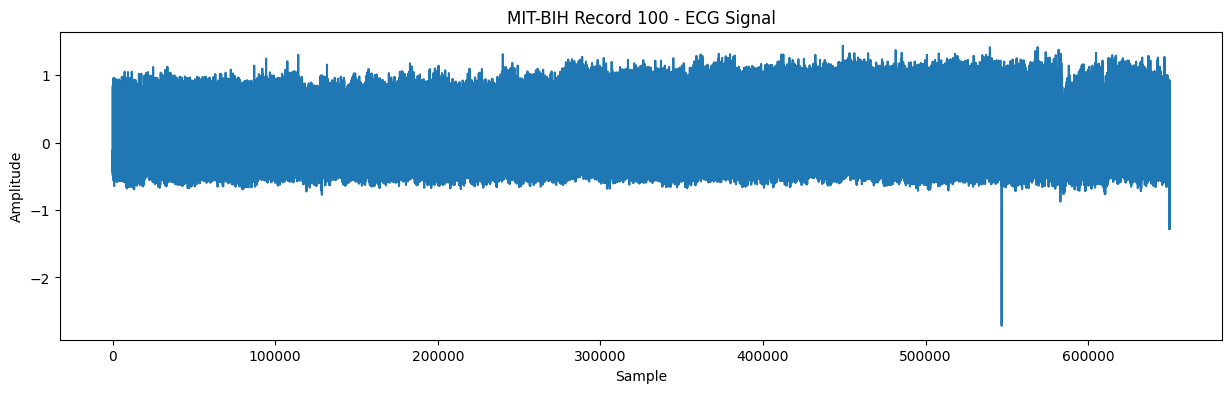

In [9]:
#plotting the record for 30 minutes
plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:, 0])

plt.title("MIT-BIH Record 100 - ECG Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

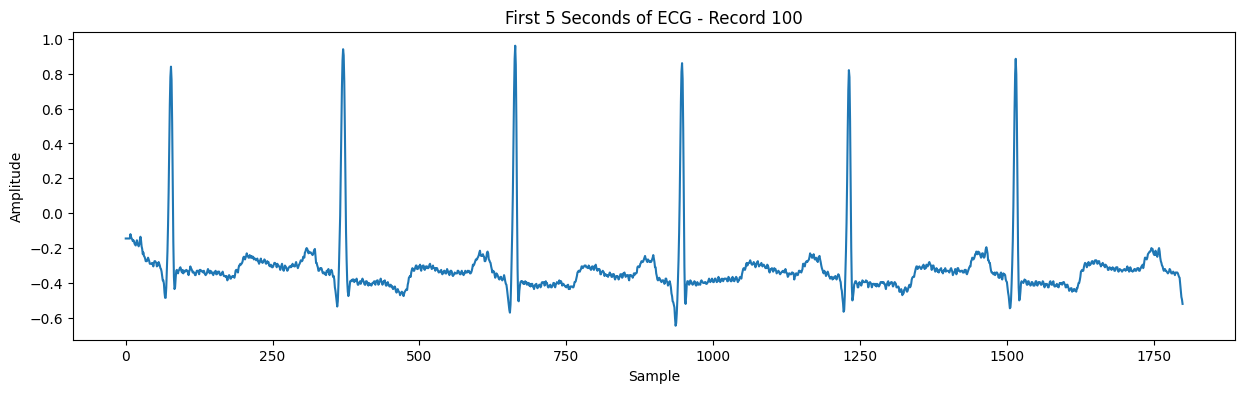

In [10]:
#5 seconds
#5*360 = 1800 samples
seconds = 5
samples = int(seconds * record.fs)

plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:samples, 0])

plt.title("First 5 Seconds of ECG - Record 100")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [11]:
#reading the annotation
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')
print(annotation)

print("Number of annotations:", len(annotation.sample))

Number of annotations: 2274


In [12]:
print("First 20 heartbeat locations:")
print(annotation.sample[:20])

First 20 heartbeat locations:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [13]:
print("First 20 labels:")
print(annotation.symbol[:20])

First 20 labels:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


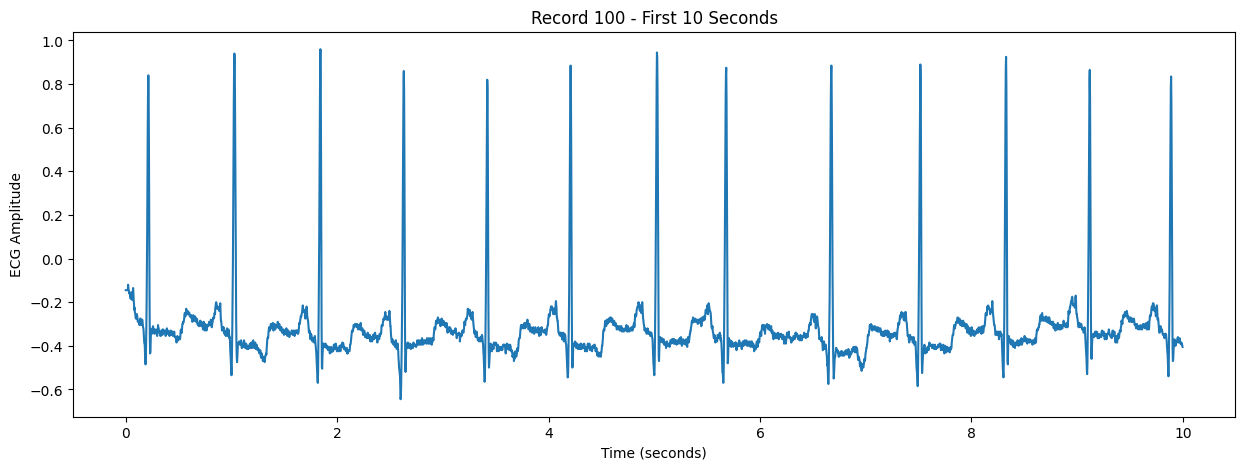

In [14]:
plt.figure(figsize=(15, 5))

plt.plot(
    np.arange(3600) / record.fs,
    record.p_signal[:3600, 0]
)

plt.title("Record 100 - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.show()

In [15]:
from collections import Counter
label_counts = Counter(annotation.symbol)
print(label_counts)

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


In [16]:
print(sorted(label_counts.keys()))

['+', 'A', 'N', 'V']


In [17]:
# First 10 seconds
samples_to_plot = 3600

# ECG signal
signal_10s = record.p_signal[:samples_to_plot, 0]

# Select only annotations inside those 10 seconds
mask = annotation.sample < samples_to_plot

ann_samples_10s = annotation.sample[mask]
ann_symbols_10s = np.array(annotation.symbol)[mask]

print("Annotations in first 10 seconds:")
print(len(ann_samples_10s))
print(ann_symbols_10s)

Annotations in first 10 seconds:
14
['+' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N']


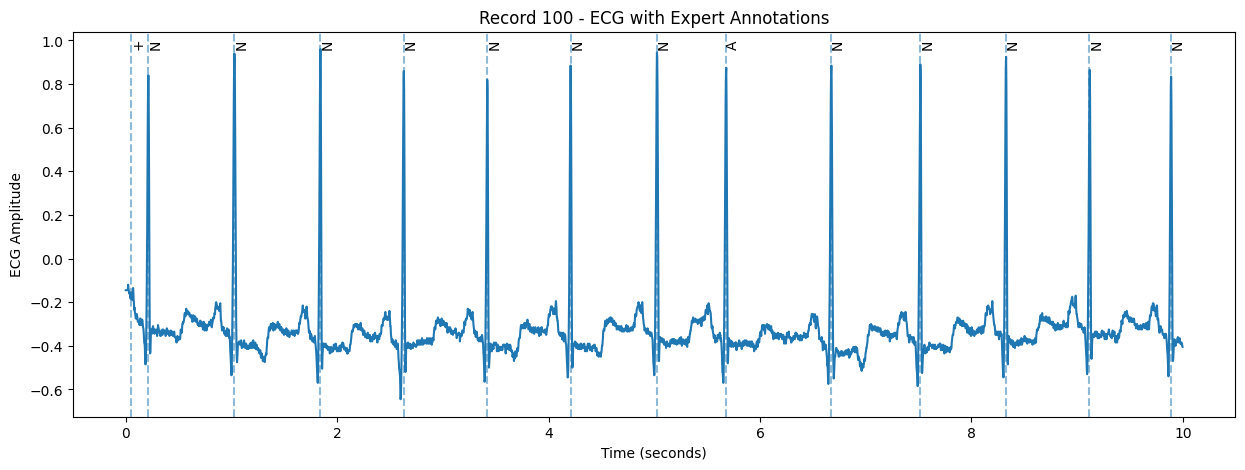

In [18]:
plt.figure(figsize=(15, 5))

# Time axis
time = np.arange(samples_to_plot) / record.fs

# ECG
plt.plot(time, signal_10s)

# Add annotation markers
for sample, symbol in zip(ann_samples_10s, ann_symbols_10s):
    time_position = sample / record.fs

    plt.axvline(time_position, linestyle='--', alpha=0.5)
    plt.text(
        time_position,
        max(signal_10s),
        symbol,
        rotation=90,
        verticalalignment='bottom'
    )

plt.title("Record 100 - ECG with Expert Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.show()

In [19]:
print("Annotation samples:")
print(ann_samples_10s)

print("\nAnnotation labels:")
print(ann_symbols_10s)

Annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560]

Annotation labels:
['+' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N']


In [20]:
# Get heartbeat locations from annotations
beat_samples = annotation.sample

# Convert samples to seconds
beat_times = beat_samples / record.fs

print("First 10 beat times:")
print(beat_times[:10])

First 10 beat times:
[0.05       0.21388889 1.02777778 1.83888889 2.62777778 3.41944444
 4.20833333 5.025      5.67777778 6.67222222]


In [21]:
rr_intervals = np.diff(beat_times)

print("First 10 RR intervals:")
print(rr_intervals[:10])


First 10 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]


In [22]:
heart_rate = 60 / np.mean(rr_intervals)

print("Approximate heart rate:", heart_rate, "BPM")

Approximate heart rate: 75.536676138855 BPM


In [23]:
beat_labels = ['N', 'A', 'V']

beat_mask = np.isin(annotation.symbol, beat_labels)

beat_samples = annotation.sample[beat_mask]
beat_symbols = np.array(annotation.symbol)[beat_mask]

print("Number of actual beats:", len(beat_samples))

print("\nFirst 20 beat labels:")
print(beat_symbols[:20])

print("\nFirst 20 beat locations:")
print(beat_samples[:20])

Number of actual beats: 2273

First 20 beat labels:
['N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N'
 'N' 'N']

First 20 beat locations:
[  77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560 3862
 4170 4466 4764 5060 5346 5633]


In [24]:
beat_times = beat_samples / record.fs

rr_intervals = np.diff(beat_times)

print("First 10 corrected RR intervals:")
print(rr_intervals[:10])

heart_rate = 60 / np.mean(rr_intervals)

print("Approximate heart rate:", heart_rate, "BPM")

First 10 corrected RR intervals:
[0.81388889 0.81111111 0.78888889 0.79166667 0.78888889 0.81666667
 0.65277778 0.99444444 0.84444444 0.81111111]
Approximate heart rate: 75.51029828561933 BPM


Data Cleaning

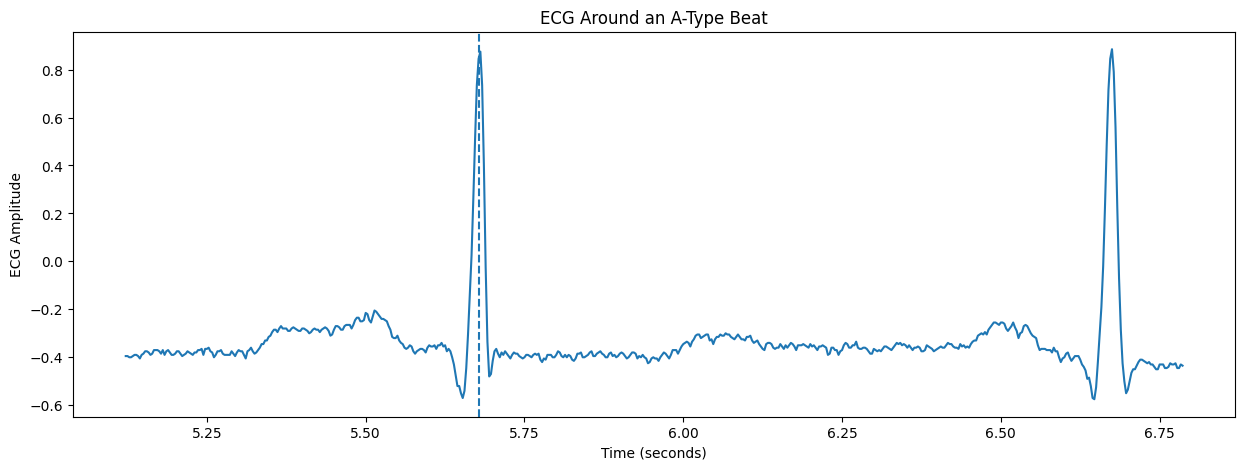

In [25]:
center = 2044

window_before = 200
window_after = 400

start = center - window_before
end = center + window_after

segment = record.p_signal[start:end, 0]

time = np.arange(start, end) / record.fs

plt.figure(figsize=(15, 5))

plt.plot(time, segment)

plt.axvline(
    center / record.fs,
    linestyle='--'
)

plt.title("ECG Around an A-Type Beat")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.show()

In [26]:
from scipy.signal import butter, filtfilt

In [27]:
fs = record.fs

low_cutoff = 0.5
high_cutoff = 40

order = 4

b, a = butter(
    order,
    [low_cutoff, high_cutoff],
    btype='bandpass',
    fs=fs
)

In [28]:
raw_signal = record.p_signal[:, 0]

filtered_signal = filtfilt(
    b,
    a,
    raw_signal
)

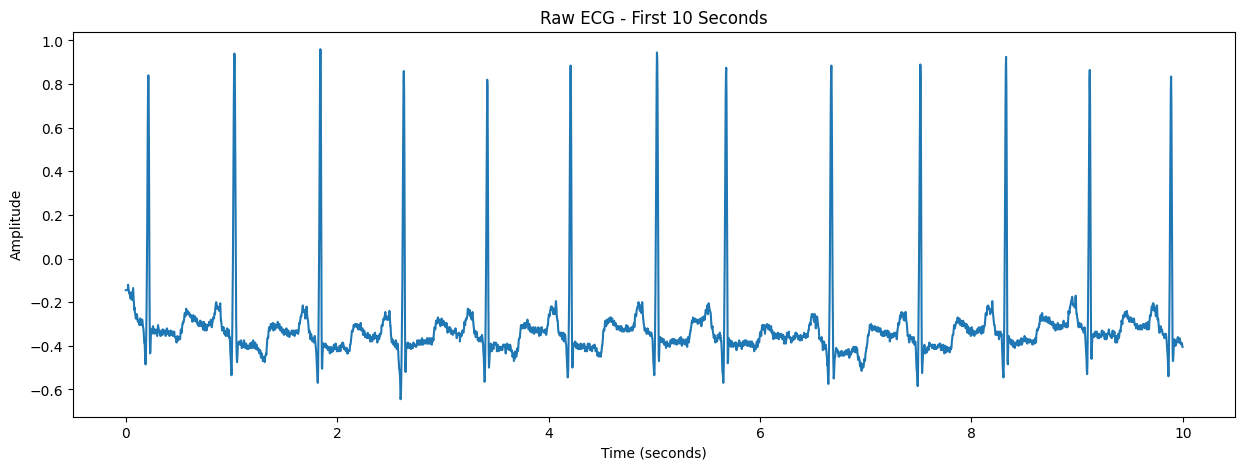

In [29]:
samples_to_plot = int(10 * fs)

time = np.arange(samples_to_plot) / fs

plt.figure(figsize=(15, 5))

plt.plot(time, raw_signal[:samples_to_plot])

plt.title("Raw ECG - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

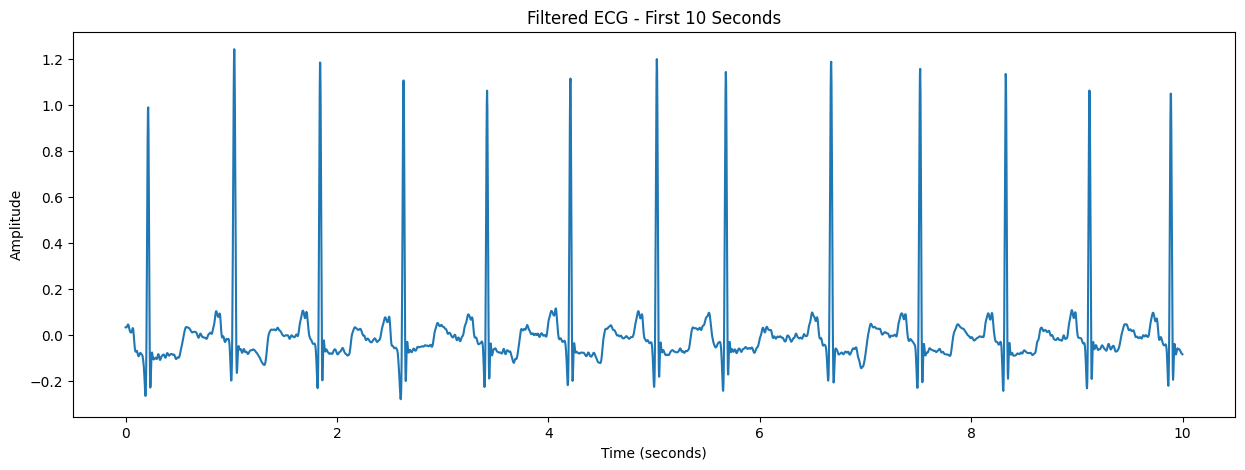

In [30]:
plt.figure(figsize=(15, 5))

plt.plot(time, filtered_signal[:samples_to_plot])

plt.title("Filtered ECG - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

R-peak detection


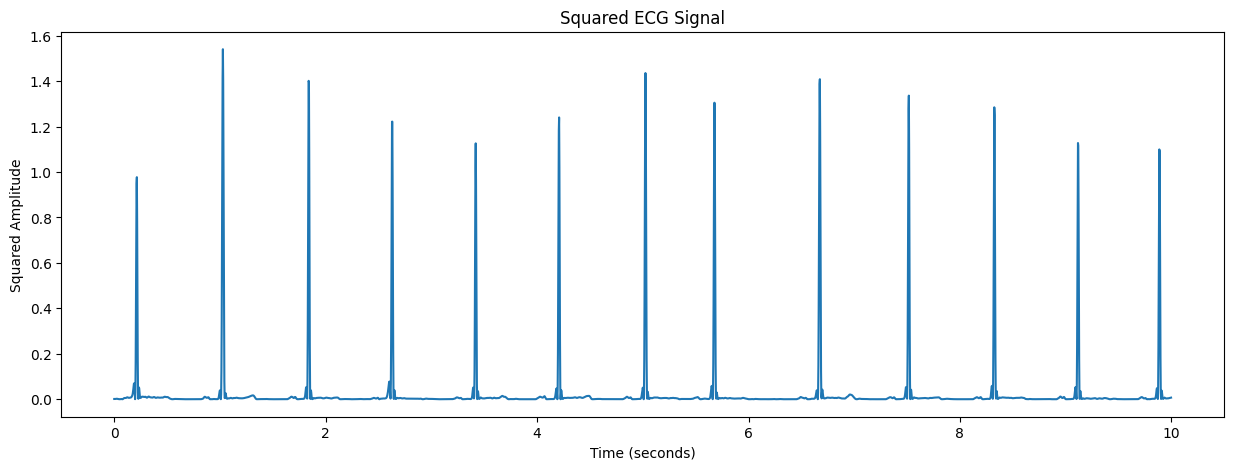

In [31]:
fs = record.fs

samples_to_plot = int(10 * fs)

ecg_10s = filtered_signal[:samples_to_plot]
squared_ecg = ecg_10s ** 2
time_10s = np.arange(samples_to_plot) / fs

plt.figure(figsize=(15, 5))

plt.plot(time_10s, squared_ecg)

plt.title("Squared ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Squared Amplitude")

plt.show()

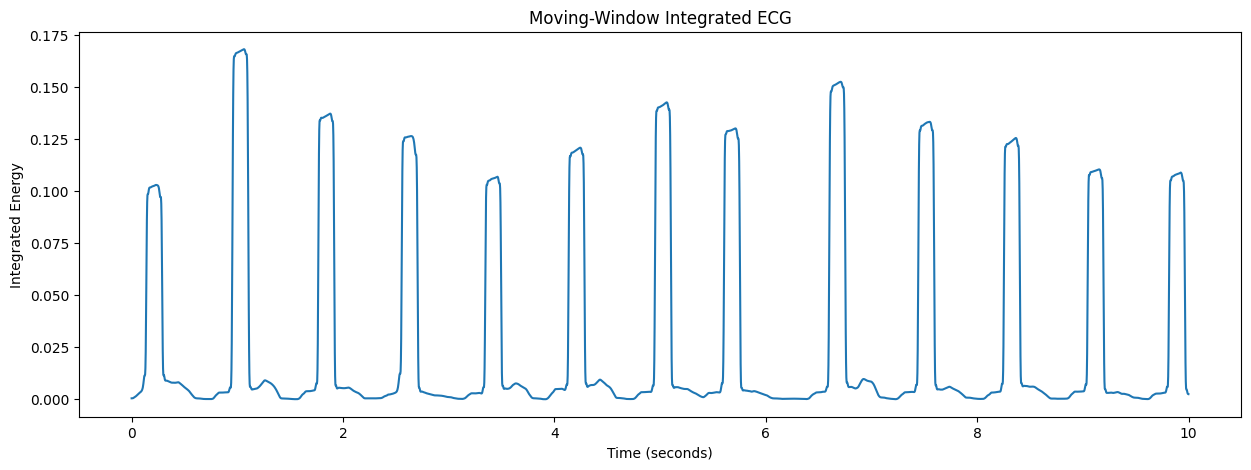

In [32]:
window_size = int(0.15 * fs)

integrated_ecg = np.convolve(
    squared_ecg,
    np.ones(window_size) / window_size,
    mode='same'
)

plt.figure(figsize=(15, 5))

plt.plot(time_10s, integrated_ecg)

plt.title("Moving-Window Integrated ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Integrated Energy")

plt.show()

In [33]:
from scipy.signal import find_peaks
threshold = 0.35 * np.max(integrated_ecg)
min_distance = int(0.25 * fs)
peaks, properties = find_peaks(
    integrated_ecg,
    height=threshold,
    distance=min_distance
)

print("Number of detected peaks:", len(peaks))
print("First 20 detected peak locations:")
print(peaks[:20])



Number of detected peaks: 13
First 20 detected peak locations:
[  84  383  676  952 1245 1528 1822 2056 2415 2718 3011 3295 3573]


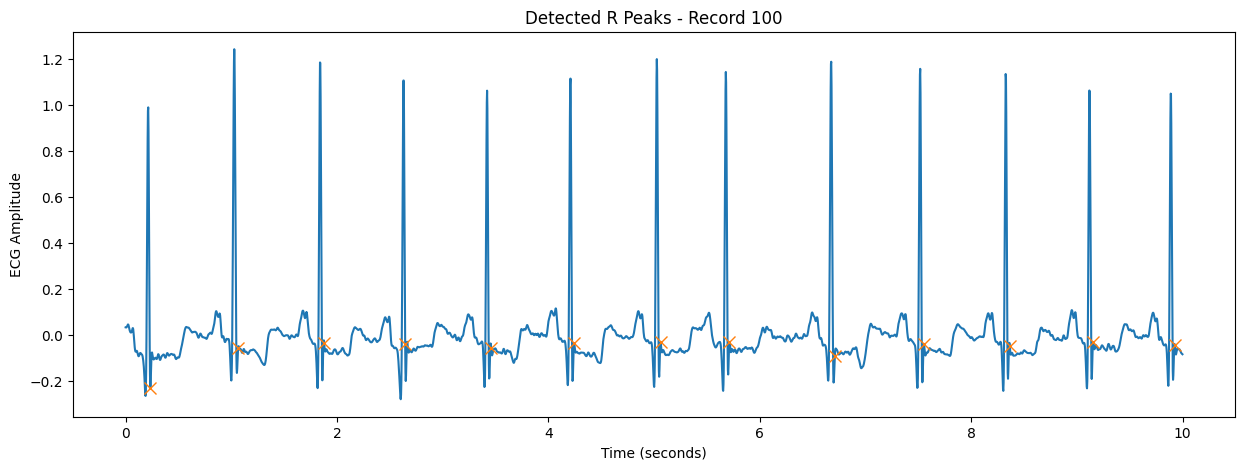

In [34]:
plt.figure(figsize=(15, 5))

plt.plot(time_10s, ecg_10s)

plt.plot(
    peaks / fs,
    ecg_10s[peaks],
    'x',
    markersize=8
)

plt.title("Detected R Peaks - Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.show()

In [35]:
refined_peaks = []

search_window = int(0.08 * fs)   # ±80 ms

for peak in peaks:
    start = max(0, peak - search_window)
    end = min(len(ecg_10s), peak + search_window)

    local_peak = start + np.argmax(ecg_10s[start:end])

    refined_peaks.append(local_peak)

refined_peaks = np.array(refined_peaks)

print("Number of refined peaks:", len(refined_peaks))
print("First 20 refined peak locations:")
print(refined_peaks[:20])

Number of refined peaks: 13
First 20 refined peak locations:
[  77  370  662  947 1231 1515 1809 2044 2403 2706 2997 3282 3559]


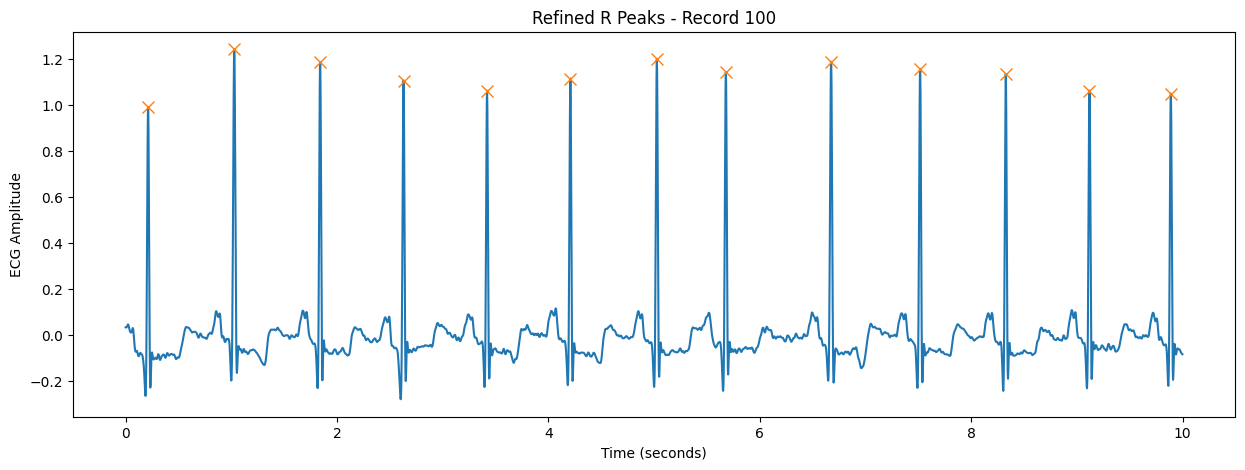

In [36]:
plt.figure(figsize=(15, 5))

plt.plot(time_10s, ecg_10s)

plt.plot(
    refined_peaks / fs,
    ecg_10s[refined_peaks],
    'x',
    markersize=8
)

plt.title("Refined R Peaks - Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")

plt.show()

In [37]:
reference_peaks = beat_samples[
    beat_samples < samples_to_plot
]

print("Reference peaks:", reference_peaks)
print("Number of reference beats:", len(reference_peaks))

Reference peaks: [  77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560]
Number of reference beats: 13


In [38]:
tolerance = int(0.10 * fs)

matched = 0

for ref in reference_peaks:
    if np.any(np.abs(refined_peaks - ref) <= tolerance):
        matched += 1

print("Reference beats:", len(reference_peaks))
print("Detected peaks:", len(refined_peaks))
print("Matched beats:", matched)
print("Tolerance:", tolerance, "samples")

Reference beats: 13
Detected peaks: 13
Matched beats: 13
Tolerance: 36 samples


In [39]:
sensitivity = matched / len(reference_peaks)

print("R-peak detection sensitivity:",
      sensitivity * 100, "%")

R-peak detection sensitivity: 100.0 %


Beat Segmentation

In [40]:
before = int(0.2 * fs)
after = int(0.4 * fs)

print("Samples before R:", before)
print("Samples after R:", after)
print("Total samples per beat:", before + after)

Samples before R: 72
Samples after R: 144
Total samples per beat: 216


In [41]:
r_peak = refined_peaks[0]

start = r_peak - before
end = r_peak + after

beat = filtered_signal[start:end]

print("R peak:", r_peak)
print("Beat length:", len(beat))

R peak: 77
Beat length: 216


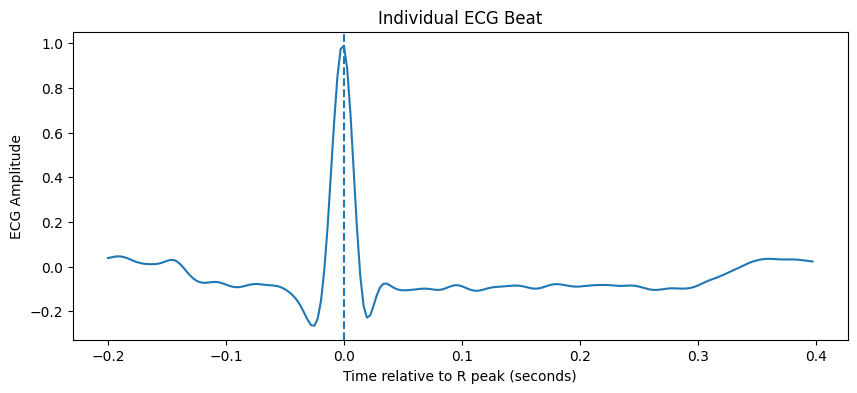

In [42]:
beat_time = np.arange(-before, after) / fs

plt.figure(figsize=(10, 4))

plt.plot(beat_time, beat)

plt.axvline(
    0,
    linestyle='--'
)

plt.title("Individual ECG Beat")
plt.xlabel("Time relative to R peak (seconds)")
plt.ylabel("ECG Amplitude")

plt.show()

In [43]:
beats = []
valid_peaks = []

for r_peak in refined_peaks:

    start = r_peak - before
    end = r_peak + after

    # Make sure the window stays inside the signal
    if start >= 0 and end <= len(filtered_signal):

        beat = filtered_signal[start:end]

        beats.append(beat)
        valid_peaks.append(r_peak)

beats = np.array(beats)
valid_peaks = np.array(valid_peaks)

print("Beat dataset shape:", beats.shape)

Beat dataset shape: (13, 216)


In [44]:
beat_labels = []
for r_peak in valid_peaks:
    distances = np.abs(beat_samples - r_peak)
    closest_index = np.argmin(distances)
    closest_distance = distances[closest_index]
    if closest_distance <= tolerance:
        beat_labels.append(
            beat_symbols[closest_index]
        )
    else:
        beat_labels.append("Unknown")
beat_labels = np.array(beat_labels)
print("Beat labels:")
print(beat_labels)

Beat labels:
['N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N']


In [45]:
print("Beat dataset shape:", beats.shape)
print("Number of labels:", len(beat_labels))

print("\nBeat labels:")
print(beat_labels)

Beat dataset shape: (13, 216)
Number of labels: 13

Beat labels:
['N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N']


In [46]:
from collections import Counter

print(Counter(beat_labels))

Counter({np.str_('N'): 12, np.str_('A'): 1})


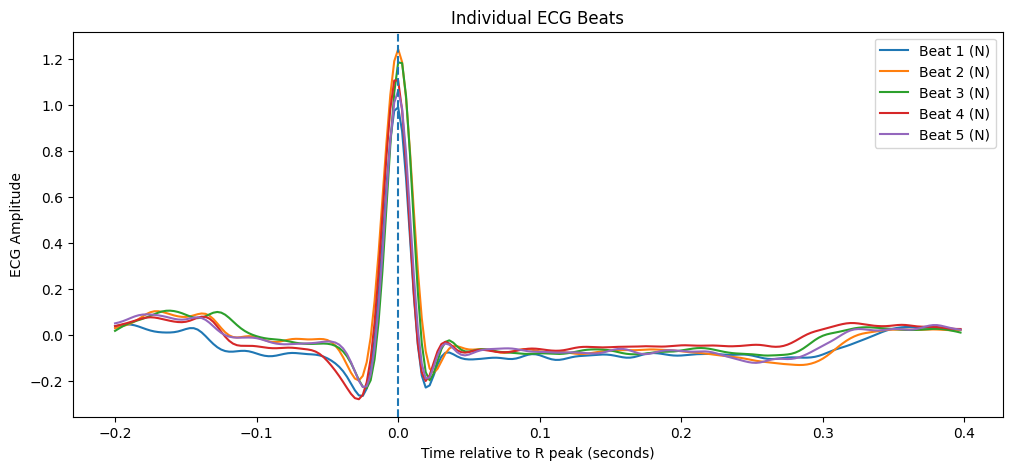

In [47]:
#plotting first few individual beats
plt.figure(figsize=(12, 5))

for i in range(min(5, len(beats))):
    plt.plot(beat_time, beats[i], label=f"Beat {i+1} ({beat_labels[i]})")

plt.axvline(0, linestyle='--')

plt.title("Individual ECG Beats")
plt.xlabel("Time relative to R peak (seconds)")
plt.ylabel("ECG Amplitude")
plt.legend()

plt.show()

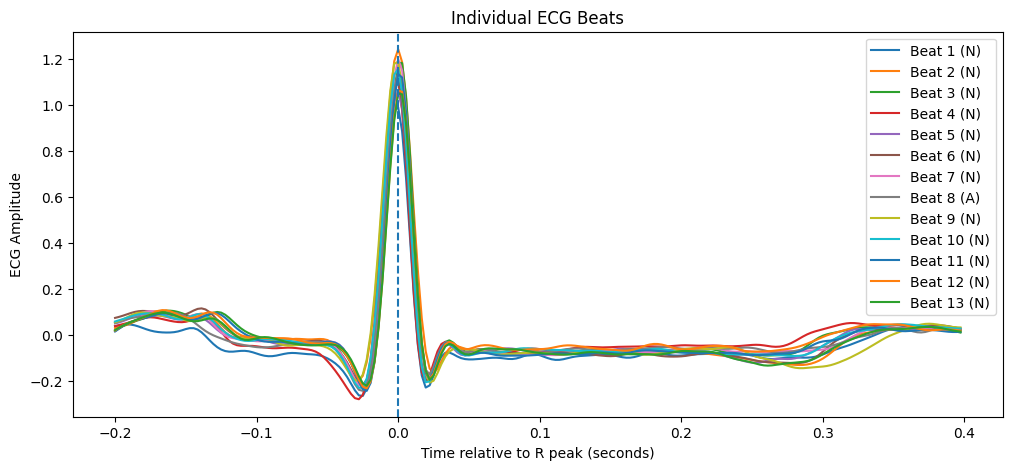

In [48]:
#visualising the actual beats
plt.figure(figsize=(12, 5))

for i in range(len(beats)):
    plt.plot(
        beat_time,
        beats[i],
        label=f"Beat {i+1} ({beat_labels[i]})"
    )

plt.axvline(0, linestyle='--')

plt.title("Individual ECG Beats")
plt.xlabel("Time relative to R peak (seconds)")
plt.ylabel("ECG Amplitude")

plt.legend()
plt.show()

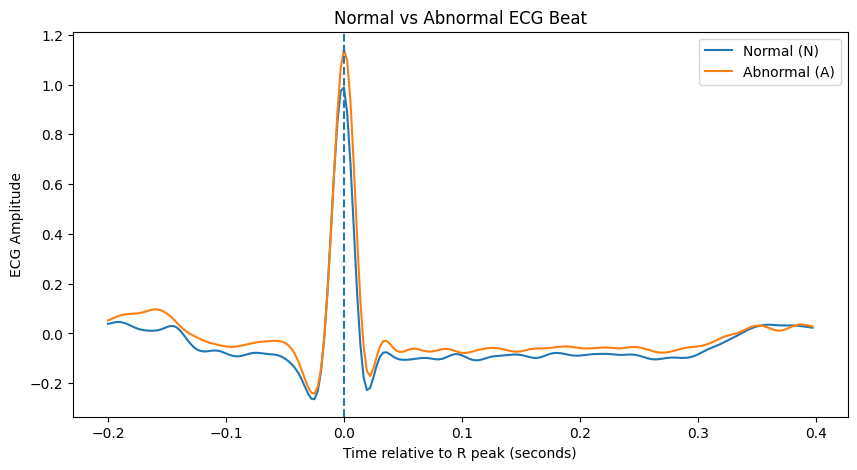

In [49]:
normal_index = np.where(beat_labels == 'N')[0][0]
abnormal_index = np.where(beat_labels == 'A')[0][0]
plt.figure(figsize=(10, 5))

plt.plot(
    beat_time,
    beats[normal_index],
    label="Normal (N)"
)

plt.plot(
    beat_time,
    beats[abnormal_index],
    label="Abnormal (A)"
)

plt.axvline(0, linestyle='--')

plt.title("Normal vs Abnormal ECG Beat")
plt.xlabel("Time relative to R peak (seconds)")
plt.ylabel("ECG Amplitude")

plt.legend()
plt.show()

In [50]:
# Full filtered ECG
full_ecg = filtered_signal

# Square the full signal
full_squared = full_ecg ** 2

# Moving-window integration
window_size = int(0.15 * fs)

full_integrated = np.convolve(
    full_squared,
    np.ones(window_size) / window_size,
    mode='same'
)

# Threshold
threshold = 0.35 * np.max(full_integrated)

# Minimum distance between beats
min_distance = int(0.25 * fs)

# Detect QRS candidates
full_peaks, properties = find_peaks(
    full_integrated,
    height=threshold,
    distance=min_distance
)

print("Number of detected candidates:", len(full_peaks))

Number of detected candidates: 2


In [51]:
full_refined_peaks = []

search_window = int(0.08 * fs)

for peak in full_peaks:

    start = max(0, peak - search_window)
    end = min(len(full_ecg), peak + search_window)

    local_peak = start + np.argmax(
        full_ecg[start:end]
    )

    full_refined_peaks.append(local_peak)

full_refined_peaks = np.array(full_refined_peaks)

print("Number of refined R peaks:", len(full_refined_peaks))

Number of refined R peaks: 2


In [52]:
print("Raw ECG length:", len(record.p_signal))
print("Filtered ECG length:", len(filtered_signal))
print("Sampling frequency:", fs)

print("Raw ECG shape:", record.p_signal.shape)
print("Filtered ECG shape:", filtered_signal.shape)

Raw ECG length: 650000
Filtered ECG length: 650000
Sampling frequency: 360
Raw ECG shape: (650000, 2)
Filtered ECG shape: (650000,)


Useful checks

In [53]:
print("Integrated signal length:", len(full_integrated))

print("Maximum:", np.max(full_integrated))
print("Mean:", np.mean(full_integrated))
print("Median:", np.median(full_integrated))

print("90th percentile:", np.percentile(full_integrated, 90))
print("95th percentile:", np.percentile(full_integrated, 95))
print("99th percentile:", np.percentile(full_integrated, 99))
print("99.5th percentile:", np.percentile(full_integrated, 99.5))

print("Location of maximum:", np.argmax(full_integrated))
print("Time of maximum:", np.argmax(full_integrated) / fs, "seconds")

Integrated signal length: 650000
Maximum: 1.4206134989512968
Mean: 0.03348795314999436
Median: 0.0051678378382650535
90th percentile: 0.1427543278904027
95th percentile: 0.1719474269288356
99th percentile: 0.22813876150325965
99.5th percentile: 0.2587004673070561
Location of maximum: 546809
Time of maximum: 1518.9138888888888 seconds


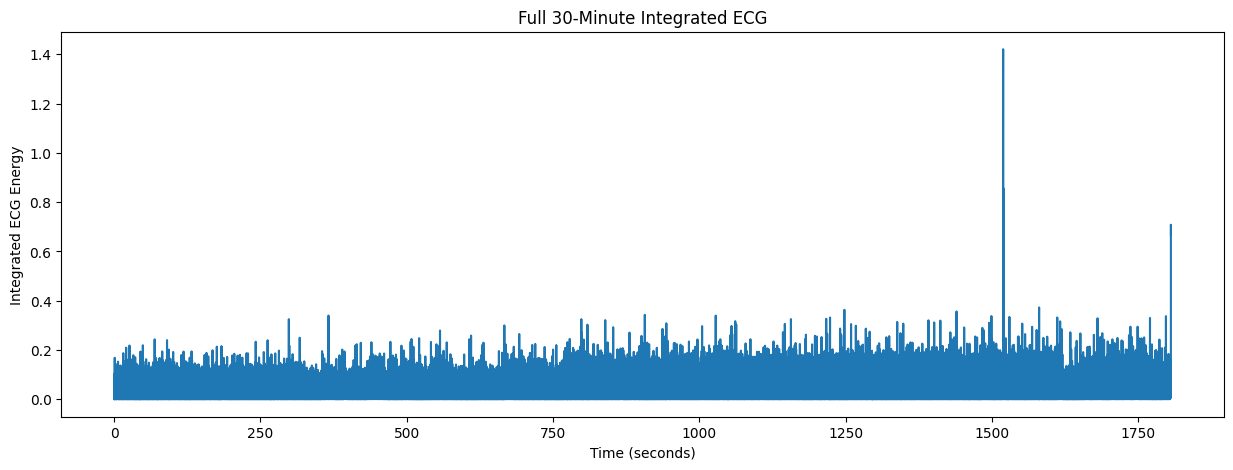

In [54]:
plt.figure(figsize=(15, 5))

plt.plot(
    np.arange(len(full_integrated)) / fs,
    full_integrated
)

plt.title("Full 30-Minute Integrated ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Integrated ECG Energy")

plt.show()

In [55]:
percentiles = [80, 85, 90, 92, 95, 97, 99]

for p in percentiles:

    threshold = np.percentile(full_integrated, p)

    test_peaks, _ = find_peaks(
        full_integrated,
        height=threshold,
        distance=int(0.25 * fs)
    )

    print(
        f"Percentile {p}% | "
        f"Threshold = {threshold:.4f} | "
        f"Peaks = {len(test_peaks)}"
    )

Percentile 80% | Threshold = 0.0397 | Peaks = 2273
Percentile 85% | Threshold = 0.1194 | Peaks = 1961
Percentile 90% | Threshold = 0.1428 | Peaks = 1339
Percentile 92% | Threshold = 0.1537 | Peaks = 1089
Percentile 95% | Threshold = 0.1719 | Peaks = 702
Percentile 97% | Threshold = 0.1895 | Peaks = 421
Percentile 99% | Threshold = 0.2281 | Peaks = 141


In [56]:
threshold = np.percentile(full_integrated, 80)

full_peaks, properties = find_peaks(
    full_integrated,
    height=threshold,
    distance=int(0.25 * fs)
)

print("Detected candidates:", len(full_peaks))

Detected candidates: 2273


In [57]:
full_refined_peaks = []

search_window = int(0.08 * fs)

for peak in full_peaks:

    start = max(0, peak - search_window)
    end = min(len(full_ecg), peak + search_window)

    local_peak = start + np.argmax(
        full_ecg[start:end]
    )

    full_refined_peaks.append(local_peak)

full_refined_peaks = np.array(full_refined_peaks)

print("Refined R peaks:", len(full_refined_peaks))

Refined R peaks: 2273


In [58]:
expert_samples = annotation.sample[
    annotation.symbol != '+'
]

expert_labels = annotation.symbol[
    annotation.symbol != '+'
]

print("Expert beats:", len(expert_samples))
print("First 10 expert locations:")
print(expert_samples[:10])

print("First 10 expert labels:")
print(expert_labels[:10])

Expert beats: 1
First 10 expert locations:
[[    18     77    370 ... 649484 649734 649991]]
First 10 expert labels:
N


In [59]:
tolerance = int(0.10 * fs)

detected = full_refined_peaks
expert = expert_samples
expert = expert.flatten() # Ensure expert is a 1D array

matched_detected = set()
matched_expert = set()

for i, d in enumerate(detected):

    differences = np.abs(expert - d)

    # Ignore expert beats already matched
    for idx in np.argsort(differences):

        if idx in matched_expert:
            continue

        if differences[idx] <= tolerance:
            matched_detected.add(i)
            matched_expert.add(idx)
            break

TP = len(matched_detected)

FP = len(detected) - TP
FN = len(expert) - TP

sensitivity = TP / (TP + FN)
precision = TP / (TP + FP)

print("True Positives:", TP)
print("False Positives:", FP)
print("False Negatives:", FN)
print("Sensitivity:", sensitivity)
print("Precision:", precision)

True Positives: 2272
False Positives: 1
False Negatives: 2
Sensitivity: 0.9991204925241864
Precision: 0.9995600527936648


In [60]:
left_samples = int(0.20 * fs)
right_samples = int(0.40 * fs)

beats = []
valid_peaks = []

for peak in full_refined_peaks:

    start = peak - left_samples
    end = peak + right_samples

    # Skip beats too close to beginning/end
    if start < 0 or end > len(full_ecg):
        continue

    beats.append(full_ecg[start:end])
    valid_peaks.append(peak)

beats = np.array(beats)
valid_peaks = np.array(valid_peaks)

print("Beat dataset shape:", beats.shape)
print("Valid peaks:", len(valid_peaks))

Beat dataset shape: (2272, 216)
Valid peaks: 2272


In [61]:
# Convert annotations to clean 1D NumPy arrays
annotation_samples = np.asarray(annotation.sample).ravel()
annotation_symbols = np.asarray(annotation.symbol).ravel()

print("Annotation samples shape:", annotation_samples.shape)
print("Annotation symbols shape:", annotation_symbols.shape)

Annotation samples shape: (2274,)
Annotation symbols shape: (2274,)


In [62]:
# Keep only actual beat annotations
beat_mask = annotation_symbols != '+'

expert_samples = annotation_samples[beat_mask]
expert_labels = annotation_symbols[beat_mask]

print("Expert beat locations shape:", expert_samples.shape)
print("Expert labels shape:", expert_labels.shape)

print("Number of expert beats:", len(expert_samples))
print("First 10 locations:", expert_samples[:10])
print("First 10 labels:", expert_labels[:10])

Expert beat locations shape: (2273,)
Expert labels shape: (2273,)
Number of expert beats: 2273
First 10 locations: [  77  370  662  946 1231 1515 1809 2044 2402 2706]
First 10 labels: ['N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N']


In [63]:
from collections import Counter

print("Class distribution:")
print(Counter(beat_labels))


Class distribution:
Counter({np.str_('N'): 12, np.str_('A'): 1})


In [64]:
print("Number of full refined peaks:", len(full_refined_peaks))
print("Number of valid peaks:", len(valid_peaks))
print("Number of beats:", len(beats))
print("Number of beat labels:", len(beat_labels))

print("\nFirst 10 refined peaks:")
print(full_refined_peaks[:10])

print("\nFirst 10 valid peaks:")
print(valid_peaks[:10])

Number of full refined peaks: 2273
Number of valid peaks: 2272
Number of beats: 2272
Number of beat labels: 13

First 10 refined peaks:
[  77  370  662  947 1231 1515 1809 2044 2403 2706]

First 10 valid peaks:
[  77  370  662  947 1231 1515 1809 2044 2403 2706]


In [65]:
# 1. Use 80th percentile threshold
threshold = np.percentile(full_integrated, 80)

# 2. Detect QRS candidates
full_peaks, _ = find_peaks(
    full_integrated,
    height=threshold,
    distance=int(0.25 * fs)
)

print("Detected candidates:", len(full_peaks))


# 3. Refine candidates to actual R peaks
full_refined_peaks = []

search_window = int(0.08 * fs)

for peak in full_peaks:

    start = max(0, peak - search_window)
    end = min(len(full_ecg), peak + search_window)

    local_peak = start + np.argmax(
        full_ecg[start:end]
    )

    full_refined_peaks.append(local_peak)

full_refined_peaks = np.array(full_refined_peaks)

print("Refined peaks:", len(full_refined_peaks))

Detected candidates: 2273
Refined peaks: 2273


In [66]:
left_samples = int(0.20 * fs)
right_samples = int(0.40 * fs)

beats = []
valid_peaks = []

for peak in full_refined_peaks:

    start = peak - left_samples
    end = peak + right_samples

    if start < 0 or end > len(full_ecg):
        continue

    beats.append(full_ecg[start:end])
    valid_peaks.append(peak)

beats = np.array(beats)
valid_peaks = np.array(valid_peaks)

print("Beat dataset shape:", beats.shape)
print("Valid peaks:", len(valid_peaks))

Beat dataset shape: (2272, 216)
Valid peaks: 2272


In [67]:
beat_labels = []

tolerance = int(0.10 * fs)

for peak in valid_peaks:

    differences = np.abs(expert_samples - peak)

    nearest_idx = np.argmin(differences)

    if differences[nearest_idx] <= tolerance:
        beat_labels.append(expert_labels[nearest_idx])
    else:
        beat_labels.append("UNKNOWN")

beat_labels = np.array(beat_labels)

print("Number of beats:", len(beats))
print("Number of labels:", len(beat_labels))
print("Class distribution:", Counter(beat_labels))

Number of beats: 2272
Number of labels: 2272
Class distribution: Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('UNKNOWN'): 1})


In [68]:
unknown_indices = np.where(beat_labels == "UNKNOWN")[0]

print("UNKNOWN indices:", unknown_indices)

for idx in unknown_indices:
    print("Index:", idx)
    print("Peak location:", valid_peaks[idx])

UNKNOWN indices: [1906]
Index: 1906
Peak location: 546836


In [69]:
for idx in unknown_indices:

    peak = valid_peaks[idx]

    differences = np.abs(expert_samples - peak)
    nearest_idx = np.argmin(differences)

    print("Detected peak:", peak)
    print("Nearest expert beat:", expert_samples[nearest_idx])
    print("Difference:", differences[nearest_idx])
    print("Nearest expert label:", expert_labels[nearest_idx])

Detected peak: 546836
Nearest expert beat: 546792
Difference: 44
Nearest expert label: V


In [70]:
beat_labels = []

tolerance = int(0.15 * fs)

for peak in valid_peaks:

    differences = np.abs(expert_samples - peak)

    nearest_idx = np.argmin(differences)

    if differences[nearest_idx] <= tolerance:
        beat_labels.append(expert_labels[nearest_idx])
    else:
        beat_labels.append("UNKNOWN")

beat_labels = np.array(beat_labels)

print("Number of beats:", len(beats))
print("Number of labels:", len(beat_labels))
print("Class distribution:", Counter(beat_labels))

Number of beats: 2272
Number of labels: 2272
Class distribution: Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('V'): 1})


NOTE: Upto here is for understanding and visualizing for data record 100.
From here on...we will be working with all the records of the dataset

In [71]:
import numpy as np
import wfdb

from scipy.signal import butter, filtfilt, find_peaks


def process_record(record_name, data_path):

    # 1. Load ECG record and annotations
    record = wfdb.rdrecord(
        f"{data_path}/{record_name}"
    )
    annotation = wfdb.rdann(
        f"{data_path}/{record_name}",
        "atr"
    )
    fs = record.fs
    # Use first ECG channel
    ecg = record.p_signal[:, 0]

    # 2. Bandpass filter
    lowcut = 0.5
    highcut = 40.0
    b, a = butter(
        3,
        [lowcut / (fs / 2),
         highcut / (fs / 2)],
        btype="band"
    )
    filtered_ecg = filtfilt(
        b,
        a,
        ecg
    )

    # 3. QRS enhancement
    squared = filtered_ecg ** 2
    window_size = int(0.15 * fs)
    integrated = np.convolve(
        squared,
        np.ones(window_size) / window_size,
        mode="same"
    )

    # 4. Detect QRS candidates
    threshold = np.percentile(
        integrated,
        80
    )
    candidate_peaks, _ = find_peaks(
        integrated,
        height=threshold,
        distance=int(0.25 * fs)
    )

    # 5. Refine R-peak locations
    refined_peaks = []
    search_window = int(0.08 * fs)
    for peak in candidate_peaks:
        start = max(
            0,
            peak - search_window
        )
        end = min(
            len(filtered_ecg),
            peak + search_window
        )
        local_peak = (
            start +
            np.argmax(
                filtered_ecg[start:end]
            )
        )
        refined_peaks.append(local_peak)
    refined_peaks = np.array(
        refined_peaks
    )

    # 6. Segment individual beats
    left_samples = int(0.20 * fs)
    right_samples = int(0.40 * fs)
    beats = []
    valid_peaks = []
    for peak in refined_peaks:
        start = peak - left_samples
        end = peak + right_samples
        if start < 0 or end > len(filtered_ecg):
            continue
        beats.append(
            filtered_ecg[start:end]
        )
        valid_peaks.append(
            peak
        )
    beats = np.array(beats)
    valid_peaks = np.array(valid_peaks)

    # 7. Prepare expert annotations
    annotation_samples = np.asarray(
        annotation.sample
    ).ravel()
    annotation_symbols = np.asarray(
        annotation.symbol
    ).ravel()

    # Remove non-beat '+' annotations
    beat_mask = annotation_symbols != "+"
    expert_samples = annotation_samples[
        beat_mask
    ]
    expert_labels = annotation_symbols[
        beat_mask
    ]

    # 8. Match each detected beat to annotation
    beat_labels = []
    tolerance = int(0.15 * fs)
    for peak in valid_peaks:
        differences = np.abs(
            expert_samples - peak
        )
        nearest_idx = np.argmin(
            differences
        )
        if differences[nearest_idx] <= tolerance:
            beat_labels.append(
                expert_labels[nearest_idx]
            )
        else:
            beat_labels.append(
                "UNKNOWN"
            )
    beat_labels = np.array(
        beat_labels
    )

    # 9. Keep only our target classes
    target_classes = ["N", "A", "V"]

    valid_mask = np.isin(
      beat_labels,
      target_classes
    )

    beats = beats[valid_mask]
    beat_labels = beat_labels[valid_mask]
    valid_peaks = valid_peaks[valid_mask]

    # 10. Return everything useful
    return (
        beats,
        beat_labels,
        valid_peaks,
        filtered_ecg,
        fs
    )

In [72]:
wfdb.dl_database('mitdb', '/content/mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [73]:
data_path = 'mitdb'

beats_100, labels_100, peaks_100, ecg_100, fs_100 = process_record(
    "100", data_path)

print("Beats:", beats_100.shape)
print("Labels:", labels_100.shape)
print("Sampling frequency:", fs_100)

from collections import Counter

print("Class distribution:")
print(Counter(labels_100))

Beats: (2272, 216)
Labels: (2272,)
Sampling frequency: 360
Class distribution:
Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('V'): 1})


In [74]:
beats_101, labels_101, peaks_101, ecg_101, fs_101 = process_record("101", data_path)

print("Beats:", beats_101.shape)
print("Labels:", labels_101.shape)
print("Sampling frequency:", fs_101)

print("\nClass distribution:")
print(Counter(labels_101))

Beats: (1863, 216)
Labels: (1863,)
Sampling frequency: 360

Class distribution:
Counter({np.str_('N'): 1860, np.str_('A'): 3})


In [75]:
test_records = ["102", "103", "104", "105"]

for record_name in test_records:

    try:

        beats, labels, peaks, ecg, fs = process_record(
            record_name,
            data_path
        )

        print("\nRecord:", record_name)
        print("Beats:", len(beats))
        print("Classes:", Counter(labels))

    except Exception as e:

        print("\nRecord:", record_name)
        print("ERROR:", e)


Record: 102
Beats: 102
Classes: Counter({np.str_('N'): 98, np.str_('V'): 4})

Record: 103
Beats: 2082
Classes: Counter({np.str_('N'): 2080, np.str_('A'): 2})

Record: 104
Beats: 165
Classes: Counter({np.str_('N'): 163, np.str_('V'): 2})

Record: 105
Beats: 2335
Classes: Counter({np.str_('N'): 2294, np.str_('V'): 41})


In [76]:
# Scanning all 48 records
import wfdb
from collections import Counter

record_names = [
    "100", "101", "102", "103", "104", "105",
    "106", "107", "108", "109", "111", "112",
    "113", "114", "115", "116", "117", "118",
    "119", "121", "122", "123", "124", "200",
    "201", "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214", "215",
    "217", "219", "220", "221", "222", "223",
    "228", "230", "231", "232", "233", "234"
]

for record_name in record_names:

    annotation = wfdb.rdann(
        f"{data_path}/{record_name}",
        "atr"
    )

    symbols = np.asarray(annotation.symbol).ravel()

    counts = Counter(symbols)
    N = counts.get("N", 0)
    A = counts.get("A", 0)
    V = counts.get("V", 0)

    print( f"{record_name}: " f"N={N}, A={A}, V={V}")

100: N=2239, A=33, V=1
101: N=1860, A=3, V=0
102: N=99, A=0, V=4
103: N=2082, A=2, V=0
104: N=163, A=0, V=2
105: N=2526, A=0, V=41
106: N=1507, A=0, V=520
107: N=0, A=0, V=59
108: N=1739, A=4, V=17
109: N=0, A=0, V=38
111: N=0, A=0, V=1
112: N=2537, A=2, V=0
113: N=1789, A=0, V=0
114: N=1820, A=10, V=43
115: N=1953, A=0, V=0
116: N=2302, A=1, V=109
117: N=1534, A=1, V=0
118: N=0, A=96, V=16
119: N=1543, A=0, V=444
121: N=1861, A=1, V=1
122: N=2476, A=0, V=0
123: N=1515, A=0, V=3
124: N=0, A=2, V=47
200: N=1743, A=30, V=826
201: N=1625, A=30, V=198
202: N=2061, A=36, V=19
203: N=2529, A=0, V=444
205: N=2571, A=3, V=71
207: N=0, A=107, V=105
208: N=1586, A=0, V=992
209: N=2621, A=383, V=1
210: N=2423, A=0, V=194
212: N=923, A=0, V=0
213: N=2641, A=25, V=220
214: N=0, A=0, V=256
215: N=3195, A=3, V=164
217: N=244, A=0, V=162
219: N=2082, A=7, V=64
220: N=1954, A=94, V=0
221: N=2031, A=0, V=396
222: N=2062, A=208, V=0
223: N=2029, A=72, V=473
228: N=1688, A=3, V=362
230: N=2255, A=0, V=1
2

In [77]:
beats_200, labels_200, peaks_200, ecg_200, fs_200 = process_record(
    "200",
    data_path
)

print("Beats:", beats_200.shape)
print("Labels:", labels_200.shape)
print("Sampling frequency:", fs_200)

print("\nClass distribution:")
print(Counter(labels_200))

Beats: (1552, 216)
Labels: (1552,)
Sampling frequency: 360

Class distribution:
Counter({np.str_('V'): 780, np.str_('N'): 760, np.str_('A'): 12})


In [78]:
selected_records = [
    "200",
    "201",
    "202",
    "209",
    "220",
    "223"
]

all_beats = []
all_labels = []
all_record_ids = []

for record_name in selected_records:

    print(f"\nProcessing record {record_name}...")

    beats, labels, peaks, ecg, fs = process_record(
        record_name,
        data_path
    )

    print("Beats:", len(beats))
    print("Classes:", Counter(labels))

    all_beats.append(beats)
    all_labels.append(labels)

    # Keep track of which record each beat came from
    all_record_ids.extend(
        [record_name] * len(beats)
    )


Processing record 200...
Beats: 1552
Classes: Counter({np.str_('V'): 780, np.str_('N'): 760, np.str_('A'): 12})

Processing record 201...
Beats: 1753
Classes: Counter({np.str_('N'): 1624, np.str_('V'): 99, np.str_('A'): 30})

Processing record 202...
Beats: 2096
Classes: Counter({np.str_('N'): 2060, np.str_('A'): 35, np.str_('V'): 1})

Processing record 209...
Beats: 2746
Classes: Counter({np.str_('N'): 2404, np.str_('A'): 341, np.str_('V'): 1})

Processing record 220...
Beats: 2046
Classes: Counter({np.str_('N'): 1952, np.str_('A'): 94})

Processing record 223...
Beats: 2175
Classes: Counter({np.str_('N'): 1849, np.str_('V'): 274, np.str_('A'): 52})


In [79]:
X = np.concatenate(
    all_beats,
    axis=0
)

y = np.concatenate(
    all_labels,
    axis=0
)

record_ids = np.array(
    all_record_ids
)

print("\n======================")
print("FINAL DATASET")
print("======================")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Record IDs:", record_ids.shape)

print("\nClass distribution:")
print(Counter(y))

print("\nRecord distribution:")
print(Counter(record_ids))


FINAL DATASET
X shape: (12368, 216)
y shape: (12368,)
Record IDs: (12368,)

Class distribution:
Counter({np.str_('N'): 10649, np.str_('V'): 1155, np.str_('A'): 564})

Record distribution:
Counter({np.str_('209'): 2746, np.str_('223'): 2175, np.str_('202'): 2096, np.str_('220'): 2046, np.str_('201'): 1753, np.str_('200'): 1552})


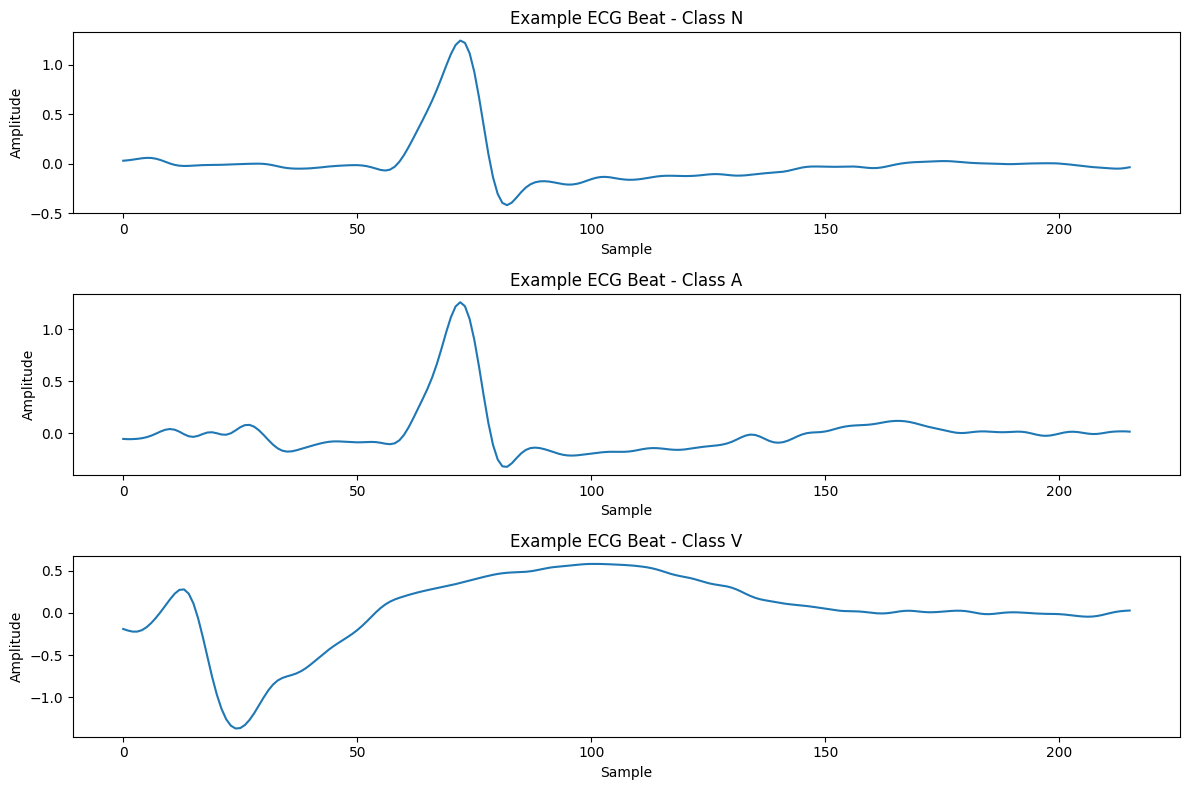

In [80]:
import matplotlib.pyplot as plt
import numpy as np

classes = ["N", "A", "V"]

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):

    indices = np.where(y == cls)[0]

    # Pick one example
    idx = indices[0]

    plt.subplot(3, 1, i + 1)

    plt.plot(X[idx])

    plt.title(f"Example ECG Beat - Class {cls}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

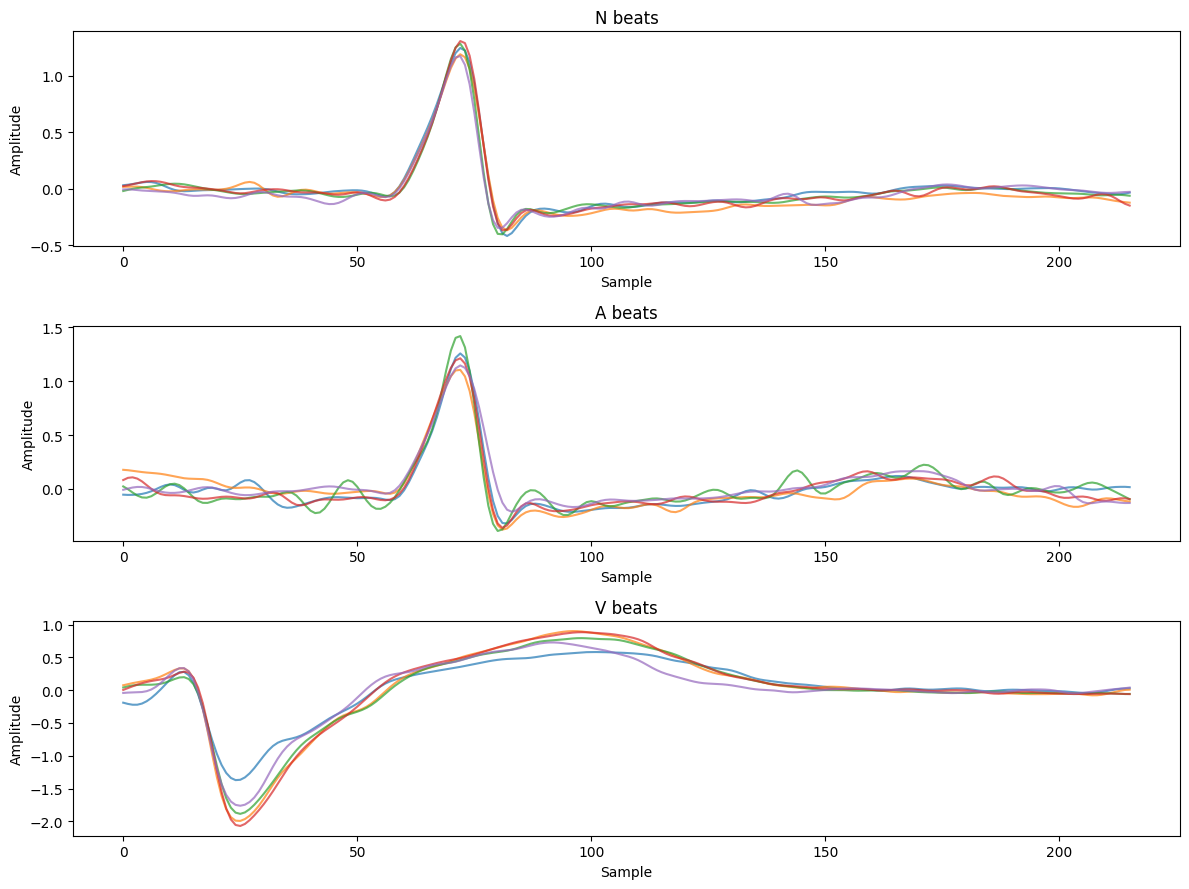

In [81]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 9)
)

for ax, cls in zip(axes, classes):

    indices = np.where(y == cls)[0]

    # Take up to 5 examples
    selected = indices[:5]

    for idx in selected:
        ax.plot(X[idx], alpha=0.7)

    ax.set_title(f"{cls} beats")
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [82]:
print("Minimum:", X.min())
print("Maximum:", X.max())
print("Mean:", X.mean())
print("Standard deviation:", X.std())

Minimum: -2.880632167472982
Maximum: 2.7697567304799984
Mean: 0.018565356785460983
Standard deviation: 0.347593173096102


In [83]:
print("\nPer-beat statistics:")

for cls in classes:

    indices = np.where(y == cls)[0]

    sample = X[indices[:100]]

    print(
        cls,
        "mean =", sample.mean(),
        "std =", sample.std(),
        "min =", sample.min(),
        "max =", sample.max()
    )


Per-beat statistics:
N mean = 0.010682868173975978 std = 0.25321291336242874 min = -0.630732152943054 max = 1.4233516673990616
A mean = 0.012767774715477782 std = 0.2815670729485952 min = -0.7535655794893102 max = 1.9964494653024638
V mean = 0.030331306186881624 std = 0.619036248113174 min = -2.3194602596586056 max = 2.2344216516012474


In [84]:
X_normalized = (
    X - X.mean(axis=1, keepdims=True)
) / (
    X.std(axis=1, keepdims=True) + 1e-8
)

print("Normalized shape:", X_normalized.shape)

print("\nFirst 5 beat means:")
print(X_normalized[:5].mean(axis=1))

print("\nFirst 5 beat standard deviations:")
print(X_normalized[:5].std(axis=1))

Normalized shape: (12368, 216)

First 5 beat means:
[ 1.64477485e-17 -3.28954970e-17  3.28954970e-17 -3.28954970e-17
  1.64477485e-17]

First 5 beat standard deviations:
[0.99999998 0.99999996 0.99999998 0.99999996 0.99999998]


pre-processing is done till here

Now on...splitting the data

In [85]:
import pandas as pd
from collections import Counter

record_class_counts = []

for record_name in selected_records:

    mask = record_ids == record_name

    labels_for_record = y[mask]

    counts = Counter(labels_for_record)

    record_class_counts.append({
        "Record": record_name,
        "N": counts.get("N", 0),
        "A": counts.get("A", 0),
        "V": counts.get("V", 0),
        "Total": len(labels_for_record)
    })

record_table = pd.DataFrame(
    record_class_counts
)

print(record_table)

  Record     N    A    V  Total
0    200   760   12  780   1552
1    201  1624   30   99   1753
2    202  2060   35    1   2096
3    209  2404  341    1   2746
4    220  1952   94    0   2046
5    223  1849   52  274   2175


In [86]:
additional_records = [
    "213",
    "215",
    "219",
    "228",
    "233"
]

additional_beats = []
additional_labels = []
additional_record_ids = []

for record_name in additional_records:

    print(f"\nProcessing record {record_name}...")

    beats, labels, peaks, ecg, fs = process_record(
        record_name,
        data_path
    )

    print("Beats:", len(beats))
    print("Classes:", Counter(labels))

    additional_beats.append(beats)
    additional_labels.append(labels)

    additional_record_ids.extend(
        [record_name] * len(beats)
    )


Processing record 213...
Beats: 2713
Classes: Counter({np.str_('N'): 2474, np.str_('V'): 214, np.str_('A'): 25})

Processing record 215...
Beats: 2891
Classes: Counter({np.str_('N'): 2725, np.str_('V'): 164, np.str_('A'): 2})

Processing record 219...
Beats: 2157
Classes: Counter({np.str_('N'): 2080, np.str_('V'): 70, np.str_('A'): 7})

Processing record 228...
Beats: 1627
Classes: Counter({np.str_('N'): 1269, np.str_('V'): 355, np.str_('A'): 3})

Processing record 233...
Beats: 2602
Classes: Counter({np.str_('N'): 1779, np.str_('V'): 818, np.str_('A'): 5})


In [87]:
X_additional = np.concatenate(
    additional_beats,
    axis=0
)

y_additional = np.concatenate(
    additional_labels,
    axis=0
)

record_ids_additional = np.array(
    additional_record_ids
)

print("\nAdditional dataset:")
print("X:", X_additional.shape)
print("y:", y_additional.shape)
print("Records:", record_ids_additional.shape)

print("\nClass distribution:")
print(Counter(y_additional))


Additional dataset:
X: (11990, 216)
y: (11990,)
Records: (11990,)

Class distribution:
Counter({np.str_('N'): 10327, np.str_('V'): 1621, np.str_('A'): 42})


In [88]:
X_additional_normalized = (
    X_additional -
    X_additional.mean(axis=1, keepdims=True)
) / (
    X_additional.std(axis=1, keepdims=True)
    + 1e-8
)

X_all = np.concatenate(
    [X_normalized, X_additional_normalized],
    axis=0
)

y_all = np.concatenate(
    [y, y_additional],
    axis=0
)

record_ids_all = np.concatenate(
    [record_ids, record_ids_additional],
    axis=0
)

print("Final X:", X_all.shape)
print("Final y:", y_all.shape)
print("Final record IDs:", record_ids_all.shape)

print("\nClasses:")
print(Counter(y_all))

print("\nRecords:")
print(Counter(record_ids_all))

Final X: (24358, 216)
Final y: (24358,)
Final record IDs: (24358,)

Classes:
Counter({np.str_('N'): 20976, np.str_('V'): 2776, np.str_('A'): 606})

Records:
Counter({np.str_('215'): 2891, np.str_('209'): 2746, np.str_('213'): 2713, np.str_('233'): 2602, np.str_('223'): 2175, np.str_('219'): 2157, np.str_('202'): 2096, np.str_('220'): 2046, np.str_('201'): 1753, np.str_('228'): 1627, np.str_('200'): 1552})


In [89]:
import pandas as pd
from collections import Counter

final_record_table = []

for record_name in sorted(np.unique(record_ids_all)):

    mask = record_ids_all == record_name
    record_labels = y_all[mask]

    counts = Counter(record_labels)

    final_record_table.append({
        "Record": record_name,
        "N": counts.get("N", 0),
        "A": counts.get("A", 0),
        "V": counts.get("V", 0),
        "Total": len(record_labels)
    })

final_record_table = pd.DataFrame(final_record_table)

print(final_record_table)

   Record     N    A    V  Total
0     200   760   12  780   1552
1     201  1624   30   99   1753
2     202  2060   35    1   2096
3     209  2404  341    1   2746
4     213  2474   25  214   2713
5     215  2725    2  164   2891
6     219  2080    7   70   2157
7     220  1952   94    0   2046
8     223  1849   52  274   2175
9     228  1269    3  355   1627
10    233  1779    5  818   2602


In [90]:
train_records = ["200","201","202","213","215","219","223"]

val_records = ["220","228"]

test_records = ["209","233"]

train_mask = np.isin(
    record_ids_all,
    train_records
)

val_mask = np.isin(
    record_ids_all,
    val_records
)

test_mask = np.isin(
    record_ids_all,
    test_records
)

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_val = X_all[val_mask]
y_val = y_all[val_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

print("TRAIN")
print("X:", X_train.shape)
print("y:", y_train.shape)
print("Classes:", Counter(y_train))

print("\nVALIDATION")
print("X:", X_val.shape)
print("y:", y_val.shape)
print("Classes:", Counter(y_val))

print("\nTEST")
print("X:", X_test.shape)
print("y:", y_test.shape)
print("Classes:", Counter(y_test))

TRAIN
X: (15337, 216)
y: (15337,)
Classes: Counter({np.str_('N'): 13572, np.str_('V'): 1602, np.str_('A'): 163})

VALIDATION
X: (3673, 216)
y: (3673,)
Classes: Counter({np.str_('N'): 3221, np.str_('V'): 355, np.str_('A'): 97})

TEST
X: (5348, 216)
y: (5348,)
Classes: Counter({np.str_('N'): 4183, np.str_('V'): 819, np.str_('A'): 346})


In [91]:
print("Train records:", set(train_records))
print("Validation records:", set(val_records))
print("Test records:", set(test_records))

print(
    "\nTrain ∩ Validation:",
    set(train_records) & set(val_records)
)

print(
    "Train ∩ Test:",
    set(train_records) & set(test_records)
)

print(
    "Validation ∩ Test:",
    set(val_records) & set(test_records)
)

Train records: {'223', '213', '200', '215', '202', '201', '219'}
Validation records: {'220', '228'}
Test records: {'233', '209'}

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [92]:
label_map = {
    "N": 0,
    "A": 1,
    "V": 2
}

y_train_encoded = np.array(
    [label_map[label] for label in y_train]
)

y_val_encoded = np.array(
    [label_map[label] for label in y_val]
)

y_test_encoded = np.array(
    [label_map[label] for label in y_test]
)

print("Encoded training labels:")
print(Counter(y_train_encoded))

print("\nEncoded validation labels:")
print(Counter(y_val_encoded))

print("\nEncoded test labels:")
print(Counter(y_test_encoded))

Encoded training labels:
Counter({np.int64(0): 13572, np.int64(2): 1602, np.int64(1): 163})

Encoded validation labels:
Counter({np.int64(0): 3221, np.int64(2): 355, np.int64(1): 97})

Encoded test labels:
Counter({np.int64(0): 4183, np.int64(2): 819, np.int64(1): 346})


Preparing data for the baseline - Random Forest

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train_encoded
)

print("Training complete!")

Training Random Forest...
Training complete!


In [94]:
y_pred_rf = rf_model.predict(
    X_test
)

print("Predictions shape:", y_pred_rf.shape)

Predictions shape: (5348,)


In [95]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred_rf,
        target_names=["N", "A", "V"],
        digits=4
    )
)

              precision    recall  f1-score   support

           N     0.9201    0.9888    0.9532      4183
           A     0.0000    0.0000    0.0000       346
           V     0.9437    0.9829    0.9629       819

    accuracy                         0.9239      5348
   macro avg     0.6213    0.6572    0.6387      5348
weighted avg     0.8642    0.9239    0.8930      5348



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


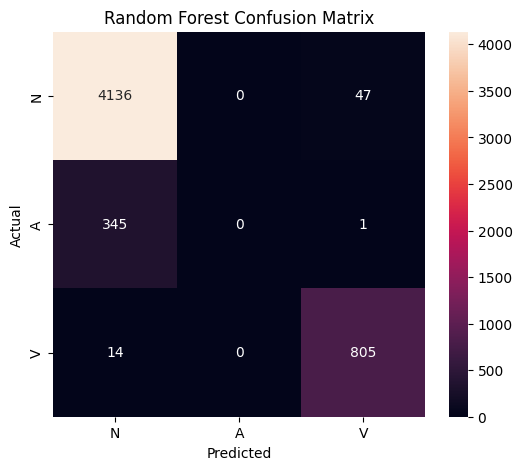

In [96]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_encoded,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["N", "A", "V"],
    yticklabels=["N", "A", "V"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_encoded,
    y_pred_rf
)

print(cm)

[[4136    0   47]
 [ 345    0    1]
 [  14    0  805]]


In [98]:
from sklearn.metrics import recall_score

sensitivity = recall_score(
    y_test_encoded,
    y_pred_rf,
    average=None,
    labels=[0, 1, 2]
)

for cls, value in zip(
    ["N", "A", "V"],
    sensitivity
):
    print(f"{cls} sensitivity: {value:.4f}")

N sensitivity: 0.9888
A sensitivity: 0.0000
V sensitivity: 0.9829


In [99]:
train_records = [
    "200",
    "201",
    "202",
    "209",
    "213",
    "215",
    "219",
    "220"
]

val_records = [
    "228"
]

test_records = [
    "223",
    "233"
]

In [100]:
train_mask = np.isin(
    record_ids_all,
    train_records
)

val_mask = np.isin(
    record_ids_all,
    val_records
)

test_mask = np.isin(
    record_ids_all,
    test_records
)

In [101]:
X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_val = X_all[val_mask]
y_val = y_all[val_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

label_map = {
    "N": 0,
    "A": 1,
    "V": 2
}

y_train_encoded = np.array(
    [label_map[label] for label in y_train]
)

y_val_encoded = np.array(
    [label_map[label] for label in y_val]
)

y_test_encoded = np.array(
    [label_map[label] for label in y_test]
)

print("TRAIN")
print("X:", X_train.shape)
print("Classes:", Counter(y_train))

print("\nVALIDATION")
print("X:", X_val.shape)
print("Classes:", Counter(y_val))

print("\nTEST")
print("X:", X_test.shape)
print("Classes:", Counter(y_test))

TRAIN
X: (17954, 216)
Classes: Counter({np.str_('N'): 16079, np.str_('V'): 1329, np.str_('A'): 546})

VALIDATION
X: (1627, 216)
Classes: Counter({np.str_('N'): 1269, np.str_('V'): 355, np.str_('A'): 3})

TEST
X: (4777, 216)
Classes: Counter({np.str_('N'): 3628, np.str_('V'): 1092, np.str_('A'): 57})


In [102]:
print(
    "Train ∩ Validation:",
    set(train_records) & set(val_records)
)

print(
    "Train ∩ Test:",
    set(train_records) & set(test_records)
)

print(
    "Validation ∩ Test:",
    set(val_records) & set(test_records)
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [103]:
train_records = [
    "200",
    "201",
    "202",
    "213",
    "215",
    "219",
    "220"
]

val_records = [
    "223"
]

test_records = [
    "209",
    "233"
]
train_mask = np.isin(record_ids_all, train_records)
val_mask = np.isin(record_ids_all, val_records)
test_mask = np.isin(record_ids_all, test_records)

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_val = X_all[val_mask]
y_val = y_all[val_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

label_map = {
    "N": 0,
    "A": 1,
    "V": 2
}

y_train_encoded = np.array([label_map[x] for x in y_train])
y_val_encoded = np.array([label_map[x] for x in y_val])
y_test_encoded = np.array([label_map[x] for x in y_test])

print("TRAIN")
print(X_train.shape)
print(Counter(y_train))

print("\nVALIDATION")
print(X_val.shape)
print(Counter(y_val))

print("\nTEST")
print(X_test.shape)
print(Counter(y_test))

print("\nRecord overlap:")
print("Train ∩ Val:", set(train_records) & set(val_records))
print("Train ∩ Test:", set(train_records) & set(test_records))
print("Val ∩ Test:", set(val_records) & set(test_records))

TRAIN
(15208, 216)
Counter({np.str_('N'): 13675, np.str_('V'): 1328, np.str_('A'): 205})

VALIDATION
(2175, 216)
Counter({np.str_('N'): 1849, np.str_('V'): 274, np.str_('A'): 52})

TEST
(5348, 216)
Counter({np.str_('N'): 4183, np.str_('V'): 819, np.str_('A'): 346})

Record overlap:
Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()


1D CNN

In [104]:
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

print("Train:", X_train_cnn.shape)
print("Validation:", X_val_cnn.shape)
print("Test:", X_test_cnn.shape)

Train: (15208, 216, 1)
Validation: (2175, 216, 1)
Test: (5348, 216, 1)


In [105]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weight_dict = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights)
}

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: 0.3707007921998781, 1: 24.728455284552844, 2: 3.817269076305221}


In [106]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(216, 1)),

    layers.Conv1D(
        filters=32,
        kernel_size=7,
        padding="same"
    ),

    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same"
    ),

    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(
        filters=128,
        kernel_size=3,
        padding="same"
    ),

    layers.BatchNormalization(),
    layers.ReLU(),

    layers.GlobalAveragePooling1D(),

    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 216, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 216, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 216, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 108, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 108, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 108, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 54, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 54, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 54, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 54, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,611 (174.26 KB)

 Trainable params: 44,163 (172.51 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn,
    y_train_encoded,

    validation_data=(
        X_val_cnn,
        y_val_encoded
    ),

    epochs=30,
    batch_size=64,

    class_weight=class_weight_dict,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.6361 - loss: 0.6017 - val_accuracy: 0.1329 - val_loss: 1.1023
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.6852 - loss: 0.4894 - val_accuracy: 0.2211 - val_loss: 1.6016
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.6896 - loss: 0.4446 - val_accuracy: 0.9251 - val_loss: 0.3626
Epoch 4/30
 59/238 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.7399 - loss: 0.5427

In [ ]:
y_prob = model.predict(
    X_test_cnn,
    batch_size=128
)

y_pred_cnn = np.argmax(
    y_prob,
    axis=1
)

print("Prediction shape:", y_pred_cnn.shape)

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred_cnn,
        target_names=["N", "A", "V"],
        digits=4
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_cnn
)

print(cm)

In [ ]:
from sklearn.metrics import recall_score

sensitivity = recall_score(
    y_test_encoded,
    y_pred_cnn,
    average=None,
    labels=[0, 1, 2]
)

for cls, value in zip(
    ["N", "A", "V"],
    sensitivity
):
    print(
        f"{cls} sensitivity: {value:.4f}"
    )

In [ ]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test_encoded,
    y_pred_cnn,
    average="macro"
)

print("Macro-F1:", macro_f1)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_cnn,
    labels=[0, 1, 2]
)

specificity = []

for i in range(3):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)

    spec = TN / (TN + FP)

    specificity.append(spec)

for cls, value in zip(
    ["N", "A", "V"],
    specificity
):
    print(f"{cls} specificity: {value:.4f}")

In [ ]:
print(type(valid_peaks))
print(valid_peaks.shape)
print(valid_peaks[:10])

print(X_test.shape)
print(y_pred_cnn.shape)
print(np.unique(record_ids_all[test_mask], return_counts=True))

In [ ]:
record_209 = wfdb.rdrecord(
    "209",
    pn_dir="mitdb"
)

print("Record 209")
print("Signal shape:", record_209.p_signal.shape)
print("Sampling frequency:", record_209.fs)

In [ ]:
annotation_209 = wfdb.rdann(
    "209",
    "atr",
    pn_dir="mitdb"
)

print("Number of annotations:", len(annotation_209.sample))
print("First 10 annotation locations:")
print(annotation_209.sample[:10])

In [ ]:
record_233 = wfdb.rdrecord(
    "233",
    pn_dir="mitdb"
)

annotation_233 = wfdb.rdann(
    "233",
    "atr",
    pn_dir="mitdb"
)

print("Record 233")
print("Signal shape:", record_233.p_signal.shape)
print("Sampling frequency:", record_233.fs)
print("Number of annotations:", len(annotation_233.sample))

In [ ]:
print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("record_ids_all:", record_ids_all.shape)

print("Unique records:")
print(np.unique(record_ids_all))

print("Test records:")
print(np.unique(record_ids_all[test_mask], return_counts=True))

In [ ]:
record_209 = wfdb.rdrecord(
    "209",
    pn_dir="mitdb"
)

ecg_209 = record_209.p_signal[:, 0]
fs = record_209.fs

print("ECG:", ecg_209.shape)
print("fs:", fs)


In [ ]:
print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("record_ids_all:", record_ids_all.shape)

test_ids = record_ids_all[test_mask]

print("\nTest record counts:")
print(Counter(test_ids))

In [ ]:
print("Available peak-related variables:")

for name in [
    "valid_peaks",
    "refined_peaks",
    "detected_candidates",
    "expert_samples",
    "beats",
    "beat_labels",
    "record_ids",
    "record_ids_all"
]:
    obj = globals().get(name, None)

    print(
        name,
        "-> type:", type(obj),
        "| shape:", getattr(obj, "shape", None)
    )

In [ ]:
print("beats shape:", beats.shape)
print("valid_peaks shape:", valid_peaks.shape)

print("\nFirst 5 valid peaks:")
print(valid_peaks[:5])

print("\nFirst beat:")
print(beats[0][:10])

print("\nLast beat:")
print(beats[-1][:10])

In [ ]:
print("beats shape:", beats.shape)
print("valid_peaks shape:", valid_peaks.shape)

print("\nFirst 5 valid peaks:")
print(valid_peaks[:5])

print("\nFirst beat first 10 samples:")
print(beats[0][:10])

print("\nSecond beat first 10 samples:")
print(beats[1][:10])

In [ ]:
print("Functions currently available:")
for name in [
    "detect_candidates",
    "refine_peaks",
    "extract_beats",
    "filter_ecg",
    "preprocess_ecg"
]:
    obj = globals().get(name, None)
    print(name, "->", obj)



In [ ]:
print("Variables:")
for name in [
    "fs",
    "filtered_ecg",
    "integrated_signal",
    "candidate_peaks",
    "refined_peaks",
    "valid_peaks"
]:
    obj = globals().get(name, None)
    print(
        name,
        "->",
        type(obj),
        getattr(obj, "shape", None)
    )

In [ ]:
print("All arrays currently available:")

for name, obj in globals().items():
    if isinstance(obj, np.ndarray):
        print(
            f"{name:30s}",
            obj.shape,
            obj.dtype
        )
print("Current record-related variables:")

for name in [
    "X_all",
    "y_all",
    "record_ids_all",
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
    "train_records",
    "val_records",
    "test_records"
]:
    obj = globals().get(name, None)

    print(
        name,
        "->",
        type(obj),
        getattr(obj, "shape", None)
    )

In [ ]:
print("peaks:", peaks.shape)
print("beats:", beats.shape)

print("\nFirst 10 peaks:")
print(peaks[:10])

print("\nLast 10 peaks:")
print(peaks[-10:])

In [ ]:
for i in range(5):
    peak_index = np.argmax(np.abs(beats[i]))
    print(
        f"Beat {i}: "
        f"peak location = {peaks[i]}, "
        f"peak inside beat = {peak_index}"
    )
print("Current labels:", Counter(labels))
print("Record 233 in final dataset:", Counter(y_all[record_ids_all == "233"]))

In [ ]:
print("Current peaks:", peaks.shape)
print("Current beats:", beats.shape)
print("Current labels:", labels.shape)

print("\nFirst 10 peaks:")
print(peaks[:10])

print("\nCurrent label distribution:")
print(Counter(labels))

print("\nFinal dataset record 233 distribution:")
print(Counter(y_all[record_ids_all == "233"]))

In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

# ecg_209 and fs are already defined from previous cells
# ecg_209: raw ECG signal for record 209
# fs: sampling frequency

# 1. Bandpass filter
lowcut = 0.5
highcut = 40.0
order = 3
b, a = butter(
    order,
    [lowcut / (fs / 2),
     highcut / (fs / 2)],
    btype="band"
)
filtered_209 = filtfilt(
    b,
    a,
    ecg_209
)

# 2. QRS enhancement (squaring and integration)
squared_209 = filtered_209 ** 2
window_size = int(0.15 * fs)
integrated_209 = np.convolve(
    squared_209,
    np.ones(window_size) / window_size,
    mode="same"
)

print("Record 209")
print("ECG:", ecg_209.shape)
print("Filtered:", filtered_209.shape)
# Removed 'Derivative:' as it's not calculated in the processing pipeline
print("Squared:", squared_209.shape)
print("Integrated:", integrated_209.shape)

print("\nIntegrated signal statistics:")
print("Min:", np.min(integrated_209))
print("Max:", np.max(integrated_209))
print("Mean:", np.mean(integrated_209))
print("Median:", np.median(integrated_209))

for p in [80, 85, 90, 92, 95, 97, 99]:
    threshold = np.percentile(integrated_209, p)

    print(
        f"{p}% | "
        f"threshold={threshold:.6f}"
    )

In [ ]:
from scipy.signal import find_peaks

print("\nPeak count at different percentiles:")

for p in [70, 75, 80, 82, 85, 87, 90, 92, 95]:

    threshold = np.percentile(integrated_209, p)

    candidates, _ = find_peaks(
        integrated_209,
        height=threshold,
        distance=int(0.25 * fs)
    )

    print(
        f"{p}% | "
        f"Threshold={threshold:.6f} | "
        f"Peaks={len(candidates)}"
    )

In [ ]:
from scipy.signal import find_peaks

threshold_209 = np.percentile(integrated_209, 80)

candidate_peaks_209, properties_209 = find_peaks(
    integrated_209,
    height=threshold_209,
    distance=int(0.25 * fs)
)

print("Threshold:", threshold_209)
print("Candidate peaks:", len(candidate_peaks_209))
print("First 10:", candidate_peaks_209[:10])

In [ ]:
refined_peaks_209 = []

search_radius = int(0.08 * fs)

for p in candidate_peaks_209:

    start = max(0, p - search_radius)
    end = min(len(filtered_209), p + search_radius + 1)

    local_segment = filtered_209[start:end]

    local_peak = np.argmax(np.abs(local_segment))

    refined_peak = start + local_peak

    refined_peaks_209.append(refined_peak)

refined_peaks_209 = np.array(refined_peaks_209)

print("Candidate peaks:", len(candidate_peaks_209))
print("Refined peaks:", len(refined_peaks_209))
print("First 20 refined peaks:")
print(refined_peaks_209[:20])

In [ ]:
min_distance = int(0.25 * fs)

clean_peaks_209 = []

for p in refined_peaks_209:

    if len(clean_peaks_209) == 0:
        clean_peaks_209.append(p)

    elif p - clean_peaks_209[-1] >= min_distance:
        clean_peaks_209.append(p)

clean_peaks_209 = np.array(clean_peaks_209)

print("Candidate peaks:", len(candidate_peaks_209))
print("Refined peaks:", len(refined_peaks_209))
print("Clean peaks:", len(clean_peaks_209))

In [ ]:
annotation_209 = wfdb.rdann(
    "209",
    "atr",
    pn_dir="mitdb"
)

expert_samples_209 = annotation_209.sample
expert_symbols_209 = np.array(annotation_209.symbol)

tolerance = int(0.10 * fs)

matched_peaks_209 = []
matched_labels_209 = []

for peak in clean_peaks_209:

    differences = np.abs(expert_samples_209 - peak)

    nearest_idx = np.argmin(differences)
    nearest_distance = differences[nearest_idx]

    if nearest_distance <= tolerance:
        matched_peaks_209.append(peak)
        matched_labels_209.append(expert_symbols_209[nearest_idx])

matched_peaks_209 = np.array(matched_peaks_209)
matched_labels_209 = np.array(matched_labels_209)

print("Detected peaks:", len(clean_peaks_209))
print("Matched to expert beats:", len(matched_peaks_209))
print("Unmatched:", len(clean_peaks_209) - len(matched_peaks_209))

print("\nClass distribution:")
print(Counter(matched_labels_209))

In [ ]:
X_209 = X_all[record_ids_all == "209"]
y_209 = y_all[record_ids_all == "209"]

print(X_209.shape)
print(Counter(y_209))

In [ ]:
for name, obj in globals().items():
    if isinstance(obj, np.ndarray):
        if len(obj.shape) == 2 and obj.shape[1] == 216:
            print(name, obj.shape)

In [ ]:
print("Record 209 X shape:",
      X_all[record_ids_all == "209"].shape)

print("Record 209 labels:")
print(Counter(y_all[record_ids_all == "209"]))

In [ ]:
print("X_209 shape:", X_209.shape)

print("First beat:")
print(X_209[0][:10])

print("\nFirst 5 expert locations:")
print(expert_samples_209[:5])

In [ ]:
print("\nFirst 20 detected 209 peaks:")
print(clean_peaks_209[:20])

In [ ]:
for i in range(5):
    p = peaks[i]

    print(
        f"Beat {i}: "
        f"ECG peak = {p}"
    )
print("First 10 peak locations:")
print(peaks[:10])

print("Differences:")
print(np.diff(peaks[:20]))

In [ ]:
print("First 10 record-233 peaks:")
print(peaks[:10])

print("\nFirst 10 differences:")
print(np.diff(peaks[:11]))

print("First 5 expert 209 locations:")
print(expert_samples_209[:5])

print("\nFirst 20 reconstructed 209 peaks:")
print(clean_peaks_209[:20])

In [ ]:
target_symbols = np.array(["N", "A", "V"])

target_mask_209 = np.isin(
    expert_symbols_209,
    target_symbols
)

target_samples_209 = expert_samples_209[target_mask_209]
target_labels_209 = expert_symbols_209[target_mask_209]

print("Target expert beats:", len(target_samples_209))
print("Distribution:")
print(Counter(target_labels_209))

print("\nFirst 20:")
print(target_samples_209[:20])
print(target_labels_209[:20])

In [ ]:
matched_target_peaks_209 = []
matched_target_labels_209 = []

tolerance = int(0.10 * fs)

for sample, label in zip(
    target_samples_209,
    target_labels_209
):

    differences = np.abs(clean_peaks_209 - sample)

    nearest_idx = np.argmin(differences)
    nearest_distance = differences[nearest_idx]

    if nearest_distance <= tolerance:
        matched_target_peaks_209.append(
            clean_peaks_209[nearest_idx]
        )
        matched_target_labels_209.append(label)

matched_target_peaks_209 = np.array(
    matched_target_peaks_209
)

matched_target_labels_209 = np.array(
    matched_target_labels_209
)

print("Matched target beats:", len(matched_target_peaks_209))

print("Class distribution:")
print(Counter(matched_target_labels_209))

In [ ]:
# Record 209: matched peaks
peaks_209_final = matched_target_peaks_209

# Record 233: already verified peaks
peaks_233_final = peaks

print("Record 209 peaks:", len(peaks_209_final))
print("Record 233 peaks:", len(peaks_233_final))

# Combine in test-dataset order
test_peak_locations = np.concatenate([
    peaks_209_final,
    peaks_233_final
])

print("Total test peak locations:", len(test_peak_locations))
print("X_test:", X_test.shape)
print("Predictions:", y_pred_cnn.shape)

In [ ]:
print("================================")
print("FINAL TEST ALIGNMENT")
print("================================")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("y_pred:", y_pred_cnn.shape)
print("Peak locations:", test_peak_locations.shape)
print("Test IDs:", test_ids.shape)

print("\nRecord distribution:")
print(Counter(test_ids))

print("\nTrue labels:")
print(Counter(y_test))

print("\nPredicted labels:")
print(Counter(y_pred_cnn))

In [ ]:
print("First 10 test records:")
print(test_ids[:10])

print("\nFirst 10 peak locations:")
print(test_peak_locations[:10])

print("\nFirst 10 true labels:")
print(y_test[:10])

print("\nFirst 10 predictions:")
print(y_pred_cnn[:10])

In [ ]:
print("\nLast 5 Record 209:")
print(test_ids[2741:2746])

print("First 5 Record 233:")
print(test_ids[2746:2751])

In [ ]:
# Convert numerical predictions back to labels
label_map = {
    0: "N",
    1: "A",
    2: "V"
}

pred_labels = np.array([
    label_map[int(p)]
    for p in y_pred_cnn
])

print("Prediction labels:")
print(Counter(pred_labels))

# Find useful examples
correct_N = np.where(
    (y_test == "N") & (pred_labels == "N")
)[0]

N_to_A = np.where(
    (y_test == "N") & (pred_labels == "A")
)[0]

A_to_N = np.where(
    (y_test == "A") & (pred_labels == "N")
)[0]

correct_A = np.where(
    (y_test == "A") & (pred_labels == "A")
)[0]

correct_V = np.where(
    (y_test == "V") & (pred_labels == "V")
)[0]

print("Correct N:", correct_N[:5])
print("N -> A:", N_to_A[:5])
print("A -> N:", A_to_N[:5])
print("Correct A:", correct_A[:5])
print("Correct V:", correct_V[:5])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_test_beat(index, window_seconds=1.5):

    record_id = test_ids[index]
    peak = test_peak_locations[index]

    true_label = y_test[index]
    pred_label = pred_labels[index]

    # Load corresponding ECG
    record = wfdb.rdrecord(
        record_id,
        pn_dir="mitdb"
    )

    ecg = record.p_signal[:, 0]
    fs_record = record.fs

    # Window around peak
    half_window = int(window_seconds * fs_record / 2)

    start = max(0, peak - half_window)
    end = min(len(ecg), peak + half_window)

    segment = ecg[start:end]

    times = (
        np.arange(start, end) - peak
    ) / fs_record

    plt.figure(figsize=(12, 4))

    plt.plot(times, segment)

    plt.axvline(
        0,
        linestyle="--",
        label="Detected R-peak"
    )

    plt.title(
        f"Record {record_id} | "
        f"Beat {index} | "
        f"True: {true_label} | "
        f"Predicted: {pred_label}"
    )

    plt.xlabel("Time relative to R-peak (seconds)")
    plt.ylabel("ECG amplitude")

    plt.legend()
    plt.grid(True)

    plt.show()

#first plot:normal beat
plot_test_beat(correct_N[0])

In [ ]:
#second plot: N->A mistake
plot_test_beat(N_to_A[0])

In [ ]:
#third plot: A->N mistake
plot_test_beat(A_to_N[0])

In [ ]:
#fourth: correct A
plot_test_beat(correct_A[0])

In [ ]:
#fifth: Ventricular beat
plot_test_beat(correct_V[0])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure predictions are converted to labels
label_map = {
    0: "N",
    1: "A",
    2: "V"
}

pred_labels = np.array([
    label_map[int(p)]
    for p in y_pred_cnn
])

# Find all mistakes
mistakes = np.where(y_test != pred_labels)[0]

print("Total mistakes:", len(mistakes))

print("\nConfusion by type:")
print("N -> A:", np.sum((y_test == "N") & (pred_labels == "A")))
print("N -> V:", np.sum((y_test == "N") & (pred_labels == "V")))
print("A -> N:", np.sum((y_test == "A") & (pred_labels == "N")))
print("A -> V:", np.sum((y_test == "A") & (pred_labels == "V")))
print("V -> N:", np.sum((y_test == "V") & (pred_labels == "N")))
print("V -> A:", np.sum((y_test == "V") & (pred_labels == "A")))

In [ ]:
# Show the first 20 classification errors
print("\nFirst 20 errors:")

for i in mistakes[:20]:
    print(
        f"Index={i:4d} | "
        f"Record={test_ids[i]} | "
        f"Peak={test_peak_locations[i]} | "
        f"True={y_test[i]} | "
        f"Pred={pred_labels[i]}"
    )

In [ ]:
import numpy as np

# Probability assigned to each class
p_N = y_prob[:, 0]
p_A = y_prob[:, 1]
p_V = y_prob[:, 2]

# Error groups
N_to_A = np.where((y_test == "N") & (pred_labels == "A"))[0]
N_to_V = np.where((y_test == "N") & (pred_labels == "V"))[0]
A_to_N = np.where((y_test == "A") & (pred_labels == "N"))[0]
A_to_V = np.where((y_test == "A") & (pred_labels == "V"))[0]

print("N -> A probability statistics")
print("Mean P(A):", np.mean(p_A[N_to_A]))
print("Median P(A):", np.median(p_A[N_to_A]))
print("Min P(A):", np.min(p_A[N_to_A]))
print("Max P(A):", np.max(p_A[N_to_A]))

print("\nA -> N probability statistics")
print("Mean P(A):", np.mean(p_A[A_to_N]))
print("Median P(A):", np.median(p_A[A_to_N]))
print("Min P(A):", np.min(p_A[A_to_N]))
print("Max P(A):", np.max(p_A[A_to_N]))

print("\nCorrect A probability statistics")
correct_A = np.where(
    (y_test == "A") & (pred_labels == "A")
)[0]

print("Mean P(A):", np.mean(p_A[correct_A]))
print("Median P(A):", np.median(p_A[correct_A]))
print("Min P(A):", np.min(p_A[correct_A]))
print("Max P(A):", np.max(p_A[correct_A]))

In [ ]:
from collections import Counter

print("================================")
print("ERRORS BY RECORD")
print("================================")

for record in np.unique(test_ids):

    mask_record = test_ids == record
    errors_record = mask_record & (y_test != pred_labels)

    print(f"\nRecord {record}")
    print("Total beats:", np.sum(mask_record))
    print("Errors:", np.sum(errors_record))
    print(
        "N -> A:",
        np.sum(
            mask_record &
            (y_test == "N") &
            (pred_labels == "A")
        )
    )
    print(
        "N -> V:",
        np.sum(
            mask_record &
            (y_test == "N") &
            (pred_labels == "V")
        )
    )
    print(
        "A -> N:",
        np.sum(
            mask_record &
            (y_test == "A") &
            (pred_labels == "N")
        )
    )
    print(
        "A -> V:",
        np.sum(
            mask_record &
            (y_test == "A") &
            (pred_labels == "V")
        )
    )

In [ ]:
print("First 10 A -> N errors:")

for i in A_to_N[:10]:
    print(
        f"Index={i} | "
        f"Record={test_ids[i]} | "
        f"Peak={test_peak_locations[i]} | "
        f"P(N)={p_N[i]:.3f} | "
        f"P(A)={p_A[i]:.3f} | "
        f"P(V)={p_V[i]:.3f}"
    )

In [ ]:
print("\nFirst 10 N -> A errors:")

for i in N_to_A[:10]:
    print(
        f"Index={i} | "
        f"Record={test_ids[i]} | "
        f"Peak={test_peak_locations[i]} | "
        f"P(N)={p_N[i]:.3f} | "
        f"P(A)={p_A[i]:.3f} | "
        f"P(V)={p_V[i]:.3f}"
    )

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

# Get validation probabilities
val_prob = model.predict(X_val_cnn, verbose=0)

p_val_N = val_prob[:, 0]
p_val_A = val_prob[:, 1]
p_val_V = val_prob[:, 2]

# Default prediction
val_pred_default = np.argmax(val_prob, axis=1)

print("Validation shape:", val_prob.shape)

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.02):

    pred = val_pred_default.copy()

    # Give A priority when P(A) exceeds threshold
    A_mask = p_val_A >= threshold
    pred[A_mask] = 1

    # But preserve strong V predictions
    V_mask = p_val_V > p_val_A
    pred[V_mask] = 2

    macro_f1 = f1_score(
        y_val_encoded,
        pred,
        average="macro"
    )

    A_f1 = f1_score(
        y_val_encoded,
        pred,
        labels=[1],
        average=None
    )[0]

    threshold_results.append(
        (threshold, macro_f1, A_f1)
    )


best = max(
    threshold_results,
    key=lambda x: x[1]
)

print("\nBest validation threshold:")
print("Threshold:", best[0])
print("Macro-F1:", best[1])
print("A-F1:", best[2])

print("Threshold | Macro-F1 | A-F1")

for threshold, macro_f1, A_f1 in threshold_results:
    print(
        f"{threshold:.2f}      | "
        f"{macro_f1:.4f}    | "
        f"{A_f1:.4f}"
    )

In [ ]:
best = max(
    threshold_results,
    key=lambda x: x[1]
)

print("\nBest validation threshold:")
print("Threshold:", best[0])
print("Macro-F1:", best[1])
print("A-F1:", best[2])

In [ ]:
print("================================")
print("VALIDATION PROBABILITY CHECK")
print("================================")

print("y_val_encoded distribution:")
print(Counter(y_val_encoded))

print("\nValidation probability shape:")
print(val_prob.shape)

print("\nProbability min:")
print(np.min(val_prob, axis=0))

print("\nProbability max:")
print(np.max(val_prob, axis=0))

print("\nProbability mean:")
print(np.mean(val_prob, axis=0))

print("\nProbability median:")
print(np.median(val_prob, axis=0))

print("\nMaximum P(A):", np.max(p_val_A))

print("\nNumber with P(A) >= 0.1:",
      np.sum(p_val_A >= 0.1))

print("Number with P(A) >= 0.2:",
      np.sum(p_val_A >= 0.2))

print("Number with P(A) >= 0.3:",
      np.sum(p_val_A >= 0.3))

print("Number with P(A) >= 0.5:",
      np.sum(p_val_A >= 0.5))

print("Number with P(A) >= 0.7:",
      np.sum(p_val_A >= 0.7))

In [ ]:
val_pred_default = np.argmax(val_prob, axis=1)

print("\nDefault validation predictions:")
print(Counter(val_pred_default))

print("\nValidation true labels:")
print(Counter(y_val_encoded))

print("\nValidation classification report:")

print(
    classification_report(
        y_val_encoded,
        val_pred_default,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

print("\nValidation confusion matrix:")
print(
    confusion_matrix(
        y_val_encoded,
        val_pred_default
    )
)

In [ ]:
print("Model output:")
print(model.output_shape)

print("\nNumber of classes:", model.output_shape[-1])

print("\nTest probabilities:")
print(y_prob[:5])

print("\nValidation probabilities:")
print(val_prob[:5])

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# A = class 1
p_A = val_prob[:, 1]

print("Validation P(A) statistics")
print("Min:", np.min(p_A))
print("Max:", np.max(p_A))
print("Mean:", np.mean(p_A))
print("Median:", np.median(p_A))

thresholds = np.arange(0.05, 0.71, 0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = np.argmax(val_prob, axis=1)

    # Force A when probability of A exceeds threshold
    y_pred_threshold[p_A >= threshold] = 1

    macro_f1 = f1_score(
        y_val_encoded,
        y_pred_threshold,
        average="macro"
    )

    a_f1 = f1_score(
        y_val_encoded,
        y_pred_threshold,
        labels=[1],
        average=None,
        zero_division=0
    )[0]

    a_recall = (
        np.sum((y_val_encoded == 1) & (y_pred_threshold == 1))
        / np.sum(y_val_encoded == 1)
    )

    num_A_predictions = np.sum(y_pred_threshold == 1)

    results.append(
        (threshold, macro_f1, a_f1, a_recall, num_A_predictions)
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"Macro-F1={macro_f1:.4f} | "
        f"A-F1={a_f1:.4f} | "
        f"A-recall={a_recall:.4f} | "
        f"Predicted A={num_A_predictions}"
    )

In [ ]:
for cls, name in [(0, "N"), (1, "A"), (2, "V")]:

    probs = val_prob[y_val_encoded == cls, 1]

    print("\n", name)
    print("Count:", len(probs))
    print("Mean P(A):", np.mean(probs))
    print("Median P(A):", np.median(probs))
    print("Max P(A):", np.max(probs))
    print("90th percentile:", np.percentile(probs, 90))
    print("95th percentile:", np.percentile(probs, 95))
    print("99th percentile:", np.percentile(probs, 99))

In [ ]:
# How many A beats are actually ranked highly by P(A)?
A_mask = (y_val_encoded == 1)

A_probs = val_prob[A_mask, 1]

for t in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:

    count = np.sum(A_probs >= t)
    recall = count / len(A_probs)

    print(
        f"P(A) >= {t:.2f}: "
        f"{count}/{len(A_probs)} "
        f"({recall:.3f})"
    )

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

print("Class weights:")
for c, w in zip(classes, weights):
    print(f"{c}: {w:.4f}")

class_weights = {
    0: 1.0,   # N
    1: 3.0,   # A
    2: 1.5    # V
}

print(class_weights)

In [ ]:
callbacks = [early_stopping]
history = model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


print("A beats by training record")
print("================================")

for record in np.unique(record_ids_all):

    mask_record = (
        (record_ids_all == record) &
        (y_all == "A")
    )

    if np.sum(mask_record) > 0:
        print(
            f"Record {record}: "
            f"{np.sum(mask_record)} A beats"
        )

In [ ]:
A_indices = np.where(y_train_encoded == 1)[0]

print("Training A beats:", len(A_indices))

print("\nFirst 20 A training indices:")
print(A_indices[:20])

print("\nTraining A record distribution:")

A_train_records = record_ids_all[train_mask][
    y_train_encoded == 1
]

print(Counter(A_train_records))

In [ ]:
# Predictions from the NEW class-weighted model
y_val_prob_new = model.predict(X_val_cnn, verbose=0)
y_val_pred_new = np.argmax(y_val_prob_new, axis=1)

print("Validation predictions:")
print(Counter(y_val_pred_new))

print("\nTrue validation labels:")
print(Counter(y_val_encoded))

print("\nValidation classification report:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred_new,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

print("\nValidation confusion matrix:")
print(
    confusion_matrix(
        y_val_encoded,
        y_val_pred_new
    )
)

p_A_new = y_val_prob_new[:, 1]

A_true = y_val_encoded == 1

print("\nNEW MODEL — A probabilities")

print("True A count:", np.sum(A_true))
print("Mean P(A) for true A:",
      np.mean(p_A_new[A_true]))
print("Median P(A) for true A:",
      np.median(p_A_new[A_true]))
print("Max P(A) for true A:",
      np.max(p_A_new[A_true]))

print("\nA predictions:")
print("Predicted A:",
      np.sum(y_val_pred_new == 1))

In [ ]:
# Training predictions
y_train_prob_new = model.predict(X_train_cnn, verbose=0)
y_train_pred_new = np.argmax(y_train_prob_new, axis=1)

print("Training predictions:")
print(Counter(y_train_pred_new))

print("\nTrue training labels:")
print(Counter(y_train_encoded))

print("\nTraining classification report:")
print(
    classification_report(
        y_train_encoded,
        y_train_pred_new,
        target_names=["N", "A", "V"],
        zero_division=0
    )
)

print("\nTraining confusion matrix:")
print(
    confusion_matrix(
        y_train_encoded,
        y_train_pred_new
    )
)

p_A_train = y_train_prob_new[:, 1]

A_train = y_train_encoded == 1

print("\nTraining A probability statistics")
print("Mean:", np.mean(p_A_train[A_train]))
print("Median:", np.median(p_A_train[A_train]))
print("Max:", np.max(p_A_train[A_train]))

print("\nTraining N probability statistics")
N_train = y_train_encoded == 0
print("Mean:", np.mean(p_A_train[N_train]))
print("Median:", np.median(p_A_train[N_train]))
print("Max:", np.max(p_A_train[N_train]))

In [ ]:
from collections import Counter
import numpy as np

print("A beats by split and record")
print("=" * 50)

# Training
train_records_array = record_ids_all[train_mask]
train_labels_array = y_all[train_mask]

print("\nTRAIN")
for record in np.unique(train_records_array):
    count = np.sum(
        (train_records_array == record) &
        (train_labels_array == "A")
    )
    if count > 0:
        print(record, count)

# Validation
val_records_array = record_ids_all[val_mask]
val_labels_array = y_all[val_mask]

print("\nVALIDATION")
for record in np.unique(val_records_array):
    count = np.sum(
        (val_records_array == record) &
        (val_labels_array == "A")
    )
    if count > 0:
        print(record, count)

# Test
test_records_array = record_ids_all[test_mask]
test_labels_array = y_all[test_mask]

print("\nTEST")
for record in np.unique(test_records_array):
    count = np.sum(
        (test_records_array == record) &
        (test_labels_array == "A")
    )
    if count > 0:
        print(record, count)

# Validation samples belonging to record 220
record_220_mask = (
    (record_ids_all[val_mask] == "220")
)

X_val_220 = X_val_cnn[record_220_mask]
y_val_220 = y_val_encoded[record_220_mask]

print("Record 220 validation shape:", X_val_220.shape)
print("Record 220 labels:", Counter(y_val_220))

if len(X_val_220) > 0:
    prob_220 = model.predict(X_val_220, verbose=0)
    pred_220 = np.argmax(prob_220, axis=1)

    print("\nPredictions:")
    print(Counter(pred_220))

    print("\nClassification report:")
    print(
        classification_report(
            y_val_220,
            pred_220,
            target_names=["N", "A", "V"],
            zero_division=0
        )
    )

    print("\nConfusion matrix:")
    print(confusion_matrix(y_val_220, pred_220))

In [ ]:
import numpy as np

print("=" * 60)
print("A MORPHOLOGY BY RECORD")
print("=" * 60)

for record in ["200", "201", "202", "213", "215", "219", "220", "223", "209", "233"]:

    mask_record = (
        (record_ids_all == record) &
        (y_all == "A")
    )

    X_record_A = X_all[mask_record]

    print(
        f"\nRecord {record}: "
        f"A beats = {X_record_A.shape[0]}"
    )

    if X_record_A.shape[0] > 0:

        mean_wave = np.mean(X_record_A, axis=0)
        std_wave = np.std(X_record_A, axis=0)

        print(
            "  Mean waveform range:",
            np.min(mean_wave),
            "to",
            np.max(mean_wave)
        )

        print(
            "  Mean beat std:",
            np.mean(std_wave)
        )

In [ ]:
from scipy.stats import pearsonr

def get_mean_A_wave(record):

    mask_record = (
        (record_ids_all == record) &
        (y_all == "A")
    )

    X_record_A = X_all[mask_record]

    if len(X_record_A) == 0:
        return None

    return np.mean(X_record_A, axis=0)


validation_A = get_mean_A_wave("223")

print("=" * 60)
print("A WAVEFORM SIMILARITY TO VALIDATION RECORD 223")
print("=" * 60)

for record in ["200", "201", "202", "213", "215", "219", "220"]:

    train_A = get_mean_A_wave(record)

    if train_A is not None:

        correlation, _ = pearsonr(
            validation_A,
            train_A
        )

        distance = np.linalg.norm(
            validation_A - train_A
        )

        print(
            f"223 vs {record}: "
            f"correlation={correlation:.4f}, "
            f"distance={distance:.4f}"
        )

In [ ]:
print("=" * 60)
print("A BEAT PEAK ALIGNMENT")
print("=" * 60)

for record in ["200", "201", "202", "213", "215", "219", "220", "223", "209"]:

    mask_record = (
        (record_ids_all == record) &
        (y_all == "A")
    )

    X_record_A = X_all[mask_record]

    if len(X_record_A) == 0:
        continue

    mean_wave = np.mean(X_record_A, axis=0)

    max_idx = np.argmax(mean_wave)
    min_idx = np.argmin(mean_wave)

    print(
        f"Record {record}: "
        f"A={len(X_record_A)}, "
        f"mean max index={max_idx}, "
        f"mean min index={min_idx}"
    )

for cls in ["N", "A", "V"]:

    mask_cls = (y_all == cls)

    mean_wave = np.mean(X_all[mask_cls], axis=0)

    print(
        f"{cls}: "
        f"max={np.argmax(mean_wave)}, "
        f"min={np.argmin(mean_wave)}"
    )

In [ ]:
print("X_train_cnn:")
print("shape:", X_train_cnn.shape)
print("min:", X_train_cnn.min())
print("max:", X_train_cnn.max())
print("mean:", X_train_cnn.mean())
print("std:", X_train_cnn.std())

print("\nX_val_cnn:")
print("shape:", X_val_cnn.shape)
print("min:", X_val_cnn.min())
print("max:", X_val_cnn.max())
print("mean:", X_val_cnn.mean())
print("std:", X_val_cnn.std())

In [ ]:
print("\nFirst training beat:")
print(X_train_cnn[0, :, 0])

print("\nFirst validation beat:")
print(X_val_cnn[0, :, 0])

In [ ]:
mean = X_train.mean()
std = X_train.std()

X_train_norm = (X_train - mean) / std
X_val_norm   = (X_val   - mean) / std
X_test_norm  = (X_test  - mean) / std

useful

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances

# ---------------------------------------------------------
# STEP 1: Extract A beats
# ---------------------------------------------------------

train_A = X_train[y_train == 'A']
train_N = X_train[y_train == 'N']
train_V = X_train[y_train == 'V']

val_A = X_val[y_val == 'A']

print("Training A:", train_A.shape)
print("Training N:", train_N.shape)
print("Training V:", train_V.shape)
print("Validation A:", val_A.shape)

In [ ]:
# ---------------------------------------------------------
# STEP 2: Correlation helper
# ---------------------------------------------------------

def correlation_matrix(A, B):
    """
    Correlation between every row of A and every row of B.
    """
    A_centered = A - A.mean(axis=1, keepdims=True)
    B_centered = B - B.mean(axis=1, keepdims=True)

    A_norm = np.linalg.norm(A_centered, axis=1, keepdims=True)
    B_norm = np.linalg.norm(B_centered, axis=1, keepdims=True)

    A_norm[A_norm == 0] = 1
    B_norm[B_norm == 0] = 1

    return (A_centered @ B_centered.T) / (A_norm @ B_norm.T)

# ---------------------------------------------------------
# STEP 3: Compare validation A against training A
# ---------------------------------------------------------

corr_A = correlation_matrix(val_A, train_A)

nearest_A_corr = np.max(corr_A, axis=1)

print("Validation A -> nearest training A")
print("Mean:", np.mean(nearest_A_corr))
print("Median:", np.median(nearest_A_corr))
print("Min:", np.min(nearest_A_corr))
print("Max:", np.max(nearest_A_corr))

In [ ]:
# ---------------------------------------------------------
# STEP 4: Compare validation A against training N and V
# ---------------------------------------------------------

corr_N = correlation_matrix(val_A, train_N)
corr_V = correlation_matrix(val_A, train_V)

nearest_N_corr = np.max(corr_N, axis=1)
nearest_V_corr = np.max(corr_V, axis=1)

print("\nValidation A -> nearest training N")
print("Mean:", np.mean(nearest_N_corr))
print("Median:", np.median(nearest_N_corr))
print("Min:", np.min(nearest_N_corr))
print("Max:", np.max(nearest_N_corr))

print("\nValidation A -> nearest training V")
print("Mean:", np.mean(nearest_V_corr))
print("Median:", np.median(nearest_V_corr))
print("Min:", np.min(nearest_V_corr))
print("Max:", np.max(nearest_V_corr))

In [ ]:
# ============================================================
# STEP 2: Nearest-neighbor analysis
# ============================================================

# Nearest indices based on correlation
nearest_A_idx = np.argmax(corr_A, axis=1)
nearest_N_idx = np.argmax(corr_N, axis=1)
nearest_V_idx = np.argmax(corr_V, axis=1)

# Corresponding correlations
best_A_corr = corr_A[np.arange(len(val_A)), nearest_A_idx]
best_N_corr = corr_N[np.arange(len(val_A)), nearest_N_idx]
best_V_corr = corr_V[np.arange(len(val_A)), nearest_V_idx]

print("Validation A nearest-neighbor correlations")
print("=" * 60)

for i in range(min(10, len(val_A))):
    print(
        f"A beat {i:2d} | "
        f"nearest A = {best_A_corr[i]:.4f} | "
        f"nearest N = {best_N_corr[i]:.4f} | "
        f"nearest V = {best_V_corr[i]:.4f}"
    )

In [ ]:
# ============================================================
# Which training class is the closest?
# ============================================================

nearest_class = np.argmax(
    np.column_stack([
        best_N_corr,
        best_A_corr,
        best_V_corr
    ]),
    axis=1
)

# 0 = N, 1 = A, 2 = V
print("\nNearest-class distribution:")
print(
    Counter(
        {0: "N", 1: "A", 2: "V"}[x]
        for x in nearest_class
    )
)

In [ ]:
# ============================================================
# Difference between nearest N and nearest A
# ============================================================

difference_N_minus_A = best_N_corr - best_A_corr

print("\nNearest N correlation - nearest A correlation")
print("Mean:", difference_N_minus_A.mean())
print("Median:", np.median(difference_N_minus_A))
print("Min:", difference_N_minus_A.min())
print("Max:", difference_N_minus_A.max())

print("\nHow many validation A beats are closer to N than A?")

print(
    np.sum(best_N_corr > best_A_corr),
    "/",
    len(val_A)
)

In [ ]:
from sklearn.metrics import pairwise_distances

# ============================================================
# STEP 3: Euclidean distance
# ============================================================

dist_A = pairwise_distances(val_A, train_A, metric='euclidean')
dist_N = pairwise_distances(val_A, train_N, metric='euclidean')
dist_V = pairwise_distances(val_A, train_V, metric='euclidean')

nearest_A_dist = np.min(dist_A, axis=1)
nearest_N_dist = np.min(dist_N, axis=1)
nearest_V_dist = np.min(dist_V, axis=1)

print("Validation A nearest-neighbor Euclidean distances")
print("=" * 60)

print("\nA -> Training A")
print("Mean:", nearest_A_dist.mean())
print("Median:", np.median(nearest_A_dist))
print("Min:", nearest_A_dist.min())
print("Max:", nearest_A_dist.max())

print("\nA -> Training N")
print("Mean:", nearest_N_dist.mean())
print("Median:", np.median(nearest_N_dist))
print("Min:", nearest_N_dist.min())
print("Max:", nearest_N_dist.max())

print("\nA -> Training V")
print("Mean:", nearest_V_dist.mean())
print("Median:", np.median(nearest_V_dist))
print("Min:", nearest_V_dist.min())
print("Max:", nearest_V_dist.max())

In [ ]:
# ============================================================
# Which class is closest by Euclidean distance?
# ============================================================

nearest_distance_class = np.argmin(
    np.column_stack([
        nearest_N_dist,
        nearest_A_dist,
        nearest_V_dist
    ]),
    axis=1
)

print("\nNearest-class distribution by Euclidean distance:")

print(
    Counter(
        {0: "N", 1: "A", 2: "V"}[x]
        for x in nearest_distance_class
    )
)

In [ ]:
# ============================================================
# Distance comparison
# ============================================================

N_minus_A = nearest_N_dist - nearest_A_dist

print("\nNearest N distance - nearest A distance")
print("Mean:", N_minus_A.mean())
print("Median:", np.median(N_minus_A))
print("Min:", N_minus_A.min())
print("Max:", N_minus_A.max())

print(
    "\nValidation A beats closer to N than A:",
    np.sum(nearest_N_dist < nearest_A_dist),
    "/",
    len(val_A)
)

In [ ]:
import numpy as np
from collections import Counter

# ------------------------------------------------------------
# STEP 1: Inspect A beats by record
# ------------------------------------------------------------

print("=" * 60)
print("A BEATS BY RECORD")
print("=" * 60)

for record in np.unique(record_ids_all):
    mask_record = record_ids_all == record
    labels_record = y_all[mask_record]

    print(
        f"Record {record}:",
        Counter(labels_record)
    )

print("\n" + "=" * 60)
print("VALIDATION RECORD DISTRIBUTION")
print("=" * 60)

print("Validation records:")
print(Counter(record_ids_all[val_mask]))

print("\nValidation labels by record:")

for record in np.unique(record_ids_all[val_mask]):
    m = val_mask & (record_ids_all == record)
    print(
        f"Record {record}:",
        Counter(y_all[m])
    )

In [ ]:
print("\n" + "=" * 60)
print("TRAINING A BEATS BY RECORD")
print("=" * 60)

train_records_actual = record_ids_all[train_mask]
train_labels_actual = y_all[train_mask]

for record in np.unique(train_records_actual):
    m = train_records_actual == record
    a_count = np.sum(train_labels_actual[m] == 'A')

    if a_count > 0:
        print(f"Record {record}: {a_count} A beats")

In [ ]:
import numpy as np

# ============================================================
# RECORD 223: A vs N MORPHOLOGY
# ============================================================

record = '223'

m223 = record_ids_all == record

X223 = X_all[m223]
y223 = y_all[m223]

A223 = X223[y223 == 'A']
N223 = X223[y223 == 'N']
V223 = X223[y223 == 'V']

print("=" * 60)
print("RECORD 223 MORPHOLOGY")
print("=" * 60)

print("A:", A223.shape)
print("N:", N223.shape)
print("V:", V223.shape)

# Mean waveforms
mean_A = np.mean(A223, axis=0)
mean_N = np.mean(N223, axis=0)
mean_V = np.mean(V223, axis=0)

# Standard deviation
std_A = np.std(A223, axis=0)
std_N = np.std(N223, axis=0)
std_V = np.std(V223, axis=0)

# Correlations between mean waveforms
corr_A_N = np.corrcoef(mean_A, mean_N)[0, 1]
corr_A_V = np.corrcoef(mean_A, mean_V)[0, 1]

# Euclidean distances
dist_A_N = np.linalg.norm(mean_A - mean_N)
dist_A_V = np.linalg.norm(mean_A - mean_V)

print("\nMean waveform correlations:")
print("A vs N:", corr_A_N)
print("A vs V:", corr_A_V)

print("\nMean waveform distances:")
print("A vs N:", dist_A_N)
print("A vs V:", dist_A_V)

print("\nMean waveform ranges:")
print("A:", mean_A.min(), "to", mean_A.max())
print("N:", mean_N.min(), "to", mean_N.max())
print("V:", mean_V.min(), "to", mean_V.max())

print("\nMean beat standard deviation:")
print("A:", np.mean(std_A))
print("N:", np.mean(std_N))
print("V:", np.mean(std_V))

In [ ]:
# ============================================================
# RECORD 223: NEAREST N / V / A
# ============================================================

def nearest_distance(query_beats, reference_beats):
    results = []

    for q in query_beats:
        distances = np.linalg.norm(reference_beats - q, axis=1)
        results.append(np.min(distances))

    return np.array(results)


A_to_N = nearest_distance(A223, N223)
A_to_V = nearest_distance(A223, V223)

print("\n" + "=" * 60)
print("RECORD 223 A-BEAT NEAREST DISTANCES")
print("=" * 60)

print("\nA -> N")
print("Mean:", np.mean(A_to_N))
print("Median:", np.median(A_to_N))
print("Min:", np.min(A_to_N))
print("Max:", np.max(A_to_N))

print("\nA -> V")
print("Mean:", np.mean(A_to_V))
print("Median:", np.median(A_to_V))
print("Min:", np.min(A_to_V))
print("Max:", np.max(A_to_V))

print("\nA beats closer to N than V:",
      np.sum(A_to_N < A_to_V),
      "/",
      len(A223))

In [ ]:
import numpy as np

# ============================================================
# RECORD 223: RR INTERVAL ANALYSIS
# ============================================================

record = '223'

m223 = record_ids_all == record

# Get the test/validation peaks belonging to record 223
peaks_223 = peaks_100[m223] if len(peaks_100) == np.sum(m223) else None

print("=" * 60)
print("RECORD 223 RR ANALYSIS")
print("=" * 60)

print("Number of Record 223 beats:", np.sum(m223))

In [ ]:
print("record_ids_all:", record_ids_all.shape)
print("X_all:", X_all.shape)
print("y_all:", y_all.shape)

print("\nUnique records:")
print(Counter(record_ids_all))

print("\nRecord 223 count:")
print(np.sum(record_ids_all == '223'))

# Check whether peak arrays have the same length as X_all

for name, arr in [
    ("peaks", peaks),
    ("peaks_100", peaks_100),
    ("full_peaks", full_peaks),
    ("beat_samples", beat_samples),
]:
    print(name, np.shape(arr))

In [ ]:
print("=" * 60)
print("RECORD-SPECIFIC VARIABLES")
print("=" * 60)

for name in dir():
    if '223' in name.lower():
        try:
            obj = globals()[name]
            print(f"{name}: type={type(obj)}, shape={np.shape(obj)}")
        except:
            pass

print("\n" + "=" * 60)
print("AVAILABLE PEAK / BEAT VARIABLES")
print("=" * 60)

for name in dir():
    if any(k in name.lower() for k in ['peak', 'beat', 'rr', 'sample']):
        try:
            obj = globals()[name]
            shape = np.shape(obj)

            if isinstance(obj, np.ndarray):
                print(f"{name:30s} {shape} {obj.dtype}")
        except:
            pass

In [ ]:
print("=" * 60)
print("LOOKING FOR RECORD 223 ECG / ANNOTATIONS")
print("=" * 60)

for name in dir():
    try:
        obj = globals()[name]

        if isinstance(obj, np.ndarray):
            shape = obj.shape

            # ECG-sized arrays
            if len(shape) == 1 and shape[0] >= 500000:
                print(f"{name:35s} shape={shape} dtype={obj.dtype}")

    except:
        pass

In [ ]:
print("\n" + "=" * 60)
print("ANNOTATION VARIABLES")
print("=" * 60)

for name in dir():
    if any(k in name.lower() for k in [
        'annotation', 'expert', 'symbol', 'label', 'sample'
    ]):
        try:
            obj = globals()[name]
            print(
                f"{name:35s} "
                f"shape={np.shape(obj)} "
                f"dtype={getattr(obj, 'dtype', None)}"
            )
        except:
            pass

In [ ]:
print("=" * 60)
print("RECORD 223 EXTRACTION TRACE")
print("=" * 60)

print("X223:", X223.shape)
print("y223:", y223.shape)

# 1. Labels
print("\nLabel distribution:")
print(Counter(y223))

# 2. Check whether X223 is actually a subset of X_all
print("\nX223 vs X_all:")
print("X_all shape:", X_all.shape)

# Find exact rows of X223 inside X_all
matches = []
for i in range(len(X223)):
    idx = np.where(np.all(np.isclose(X_all, X223[i], atol=1e-8), axis=1))[0]
    if len(idx) > 0:
        matches.append(idx[0])

print("Matched X223 rows in X_all:", len(matches))

if len(matches) > 0:
    matches = np.array(matches)
    print("First 20 X_all indices:", matches[:20])
    print("First 20 corresponding records:", record_ids_all[matches[:20]])
    print("Record distribution of matched rows:")
    print(Counter(record_ids_all[matches]))

# 3. Check validation arrays directly
print("\nValidation arrays:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("val_records_array:", val_records_array.shape)

print("Validation record distribution:")
print(Counter(val_records_array))

# 4. Check whether X223 == X_val
print("\nX223 == X_val?")
print("Shape equal:", X223.shape == X_val.shape)

if X223.shape == X_val.shape:
    print("All close:", np.allclose(X223, X_val, atol=1e-8))
    print("Labels equal:", np.array_equal(y223, y_val))

# 5. Inspect first few A beats
A_idx = np.where(y223 == 'A')[0]

print("\nFirst 20 A indices in X223:")
print(A_idx[:20])

print("\nFirst 20 A waveforms:")
for i in A_idx[:5]:
    print("\nIndex:", i)
    print("Record:", val_records_array[i])
    print("Label:", y223[i])
    print("Waveform first 10:", X223[i][:10])
    print("Waveform max index:", np.argmax(X223[i]))
    print("Waveform min index:", np.argmin(X223[i]))

# 6. Check normalization consistency
print("\nNormalization:")
print("X223 mean:", X223.mean())
print("X223 std:", X223.std())
print("X223 min:", X223.min())
print("X223 max:", X223.max())

print("X_val mean:", X_val.mean())
print("X_val std:", X_val.std())
print("X_val min:", X_val.min())
print("X_val max:", X_val.max())

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

print("=" * 60)
print("RECORD 223: A vs N SEPARABILITY")
print("=" * 60)

# ---------------------------------------------------------
# 1. Basic waveform statistics
# ---------------------------------------------------------

A = X223[y223 == 'A']
N = X223[y223 == 'N']

print("A:", A.shape)
print("N:", N.shape)

# Per-beat features
A_amp = A.max(axis=1) - A.min(axis=1)
N_amp = N.max(axis=1) - N.min(axis=1)

A_mean = A.mean(axis=1)
N_mean = N.mean(axis=1)

A_std = A.std(axis=1)
N_std = N.std(axis=1)

A_area = np.sum(np.abs(A), axis=1)
N_area = np.sum(np.abs(N), axis=1)

features = {
    "Amplitude": (A_amp, N_amp),
    "Mean": (A_mean, N_mean),
    "Std": (A_std, N_std),
    "AbsArea": (A_area, N_area),
}

for name, (a, n) in features.items():

    print("\n" + name)

    print(
        "A: mean={:.5f}, median={:.5f}, std={:.5f}".format(
            np.mean(a),
            np.median(a),
            np.std(a)
        )
    )

    print(
        "N: mean={:.5f}, median={:.5f}, std={:.5f}".format(
            np.mean(n),
            np.median(n),
            np.std(n)
        )
    )

    # AUC: can this single feature distinguish A from N?
    scores = np.concatenate([a, n])
    labels = np.concatenate([
        np.ones(len(a)),
        np.zeros(len(n))
    ])

    auc = roc_auc_score(labels, scores)

    # AUC is symmetric around 0.5
    auc_effective = max(auc, 1 - auc)

    print("AUC:", auc)
    print("Effective AUC:", auc_effective)


# ---------------------------------------------------------
# 2. Point-by-point A vs N difference
# ---------------------------------------------------------

mean_A = A.mean(axis=0)
mean_N = N.mean(axis=0)

difference = np.abs(mean_A - mean_N)

print("\n" + "=" * 60)
print("MEAN A vs N WAVEFORM DIFFERENCE")
print("=" * 60)

print("Mean absolute difference:", difference.mean())
print("Maximum absolute difference:", difference.max())
print("Largest difference index:", np.argmax(difference))

print("\nTop 20 difference indices:")
top_idx = np.argsort(difference)[-20:][::-1]
print(top_idx)

print("\nDifferences:")
print(difference[top_idx])


# ---------------------------------------------------------
# 3. Compare A and N around QRS region
# ---------------------------------------------------------

regions = {
    "0-50": (0, 50),
    "50-70": (50, 70),
    "70-80": (70, 80),
    "80-100": (80, 100),
    "100-130": (100, 130),
    "130-160": (130, 160),
    "160-190": (160, 190),
    "190-216": (190, 216),
}

print("\n" + "=" * 60)
print("REGIONAL A vs N DIFFERENCE")
print("=" * 60)

for name, (start, end) in regions.items():

    diff = np.mean(
        np.abs(
            A[:, start:end].mean(axis=0)
            -
            N[:, start:end].mean(axis=0)
        )
    )

    print(
        "{:<10} mean absolute difference = {:.6f}".format(
            name,
            diff
        )
    )


# ---------------------------------------------------------
# 4. Nearest-neighbor baseline INSIDE record 223
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("WITHIN-RECORD-223 NEAREST NEIGHBOR")
print("=" * 60)

# Pairwise Euclidean distances
from sklearn.metrics import pairwise_distances

D_A_N = pairwise_distances(A, N)

nearest_N_for_A = D_A_N.min(axis=1)

# A-to-A distances, ignore self-distance
D_A_A = pairwise_distances(A, A)
D_A_A[D_A_A == 0] = np.inf

nearest_A_for_A = D_A_A.min(axis=1)

print(
    "A -> nearest N:"
    "\nMean:", nearest_N_for_A.mean(),
    "\nMedian:", np.median(nearest_N_for_A),
    "\nMin:", nearest_N_for_A.min(),
    "\nMax:", nearest_N_for_A.max()
)

print(
    "\nA -> nearest OTHER A:"
    "\nMean:", nearest_A_for_A.mean(),
    "\nMedian:", np.median(nearest_A_for_A),
    "\nMin:", nearest_A_for_A.min(),
    "\nMax:", nearest_A_for_A.max()
)

print(
    "\nA beats where nearest N is closer than nearest A:",
    np.sum(nearest_N_for_A < nearest_A_for_A),
    "/",
    len(A)
)

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=" * 60)
print("STEP 3: HANDCRAFTED A vs N CLASSIFIER")
print("=" * 60)


# ---------------------------------------------------------
# Feature extraction
# ---------------------------------------------------------

def extract_features(X):

    features = []

    for beat in X:

        f = []

        # Basic morphology
        f.append(np.max(beat) - np.min(beat))
        f.append(np.sum(np.abs(beat)))
        f.append(np.sum(beat ** 2))

        # Maximum / minimum
        f.append(np.argmax(beat))
        f.append(np.argmin(beat))

        # Selected waveform values
        for idx in [10, 20, 30, 40, 50,
                    60, 65, 70, 72, 75, 80, 90,
                    100, 110, 120, 130, 140, 150,
                    160, 170, 180, 190, 200]:

            f.append(beat[idx])

        # Regional absolute areas
        regions = [
            (0, 30),
            (30, 60),
            (60, 90),
            (90, 120),
            (120, 150),
            (150, 180),
            (180, 216)
        ]

        for start, end in regions:
            f.append(np.sum(np.abs(beat[start:end])))

        # Regional energy
        for start, end in regions:
            f.append(np.sum(beat[start:end] ** 2))

        features.append(f)

    return np.asarray(features)


# ---------------------------------------------------------
# Training data: ONLY A and N
# ---------------------------------------------------------

train_A = X_train[y_train == 'A']
train_N = X_train[y_train == 'N']

val_A = X_val[y_val == 'A']
val_N = X_val[y_val == 'N']

print("\nTraining:")
print("A:", train_A.shape)
print("N:", train_N.shape)

print("\nValidation:")
print("A:", val_A.shape)
print("N:", val_N.shape)


# ---------------------------------------------------------
# Extract features
# ---------------------------------------------------------

Xtr_A = extract_features(train_A)
Xtr_N = extract_features(train_N)

Xva_A = extract_features(val_A)
Xva_N = extract_features(val_N)

Xtr = np.vstack([Xtr_A, Xtr_N])
ytr = np.concatenate([
    np.ones(len(Xtr_A)),
    np.zeros(len(Xtr_N))
])

Xva = np.vstack([Xva_A, Xva_N])
yva = np.concatenate([
    np.ones(len(Xva_A)),
    np.zeros(len(Xva_N))
])

print("\nFeature shape:", Xtr.shape)


# ---------------------------------------------------------
# Random forest
# ---------------------------------------------------------

clf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_depth=8
)

clf.fit(Xtr, ytr)


# ---------------------------------------------------------
# Validation performance
# ---------------------------------------------------------

p = clf.predict_proba(Xva)[:, 1]

pred = (p >= 0.5).astype(int)

print("\n" + "=" * 60)
print("VALIDATION A vs N")
print("=" * 60)

print(classification_report(
    yva,
    pred,
    target_names=['N', 'A']
))

print("Confusion matrix:")
print(confusion_matrix(yva, pred))

print("AUC:", roc_auc_score(yva, p))


# ---------------------------------------------------------
# Probability statistics
# ---------------------------------------------------------

print("\nP(A) statistics")

print("\nTrue A:")
print("Mean:", p[yva == 1].mean())
print("Median:", np.median(p[yva == 1]))
print("Min:", p[yva == 1].min())
print("Max:", p[yva == 1].max())

print("\nTrue N:")
print("Mean:", p[yva == 0].mean())
print("Median:", np.median(p[yva == 0]))
print("Min:", p[yva == 0].min())
print("Max:", p[yva == 0].max())


# ---------------------------------------------------------
# Feature importance
# ---------------------------------------------------------

importance = clf.feature_importances_

top = np.argsort(importance)[::-1][:20]

print("\n" + "=" * 60)
print("TOP FEATURES")
print("=" * 60)

for i in top:
    print(
        "Feature {:3d} | importance = {:.6f}".format(
            i,
            importance[i]
        )
    )

In [ ]:
import numpy as np

print("=" * 60)
print("STEP 4: RECORD 223 RR INTERVAL ANALYSIS")
print("=" * 60)

# ---------------------------------------------------------
# IMPORTANT:
# X223 contains 2175 beats.
# We need the peak locations corresponding to THESE beats.
# ---------------------------------------------------------

print("X223 shape:", X223.shape)
print("y223 shape:", y223.shape)

# Find X223 rows inside X_all
idx223 = np.where(record_ids_all == '223')[0]

print("X223 indices:", idx223.shape)

# Verify ordering
print("First indices:", idx223[:10])
print("Last indices:", idx223[-10:])

# Peak locations belonging to those rows
peaks223 = test_peak_locations[test_records_array == '233'] if False else None

In [ ]:
  print("=" * 60)
print("STEP 4B: FIND PEAKS FOR X223")
print("=" * 60)

# X223 corresponds to these X_all rows
idx223 = np.where(record_ids_all == '223')[0]

# ---------------------------------------------------------
# Check candidate peak arrays
# ---------------------------------------------------------

candidates = {
    "peaks": peaks,
    "peaks_100": peaks_100,
    "full_peaks": full_peaks,
    "beat_samples": beat_samples,
    "valid_peaks": valid_peaks,
}

for name, arr in candidates.items():

    print(
        f"{name:15s} "
        f"shape={np.shape(arr)} "
        f"dtype={getattr(arr, 'dtype', None)}"
    )

    if arr is None:
        continue

    # A peak array can only correspond directly to X_all
    # if it has the same number of rows.
    if len(arr) == len(X_all):
        print("   *** SAME LENGTH AS X_all ***")

    # Check whether length matches X223
    if len(arr) == len(X223):
        print("   *** SAME LENGTH AS X223 ***")

print()
print("X_all:", X_all.shape)
print("idx223:", idx223.shape)
print("X223:", X223.shape)

In [ ]:
print("=" * 60)
print("STEP 4C: IDENTIFY RECORD 223 PEAKS")
print("=" * 60)

# Check all integer arrays in the workspace whose names
# suggest they may contain peak/sample locations.

import numpy as np

for name in sorted(list(globals().keys())):

    try:
        obj = globals()[name]

        if isinstance(obj, np.ndarray):
            if obj.ndim == 1 and np.issubdtype(obj.dtype, np.integer):

                # Candidate peak/sample arrays
                if (
                    "peak" in name.lower()
                    or "sample" in name.lower()
                    or "beat" in name.lower()
                ):
                    print(
                        f"{name:30s} "
                        f"shape={obj.shape} "
                        f"min={obj.min() if len(obj) else 'empty'} "
                        f"max={obj.max() if len(obj) else 'empty'}"
                    )

    except Exception:
        pass

In [ ]:
print("=" * 60)
print("STEP 4D: FIND X_ALL -> PEAK MAPPING")
print("=" * 60)

import numpy as np

# Print ALL 1-D arrays whose length equals the number of beats
# in X_all.
for name in sorted(globals().keys()):
    try:
        obj = globals()[name]

        if isinstance(obj, np.ndarray):
            if obj.ndim == 1 and len(obj) == len(X_all):
                print(
                    f"{name:35s} "
                    f"shape={obj.shape} "
                    f"dtype={obj.dtype}"
                )

    except Exception:
        pass

print()
print("Number of X_all rows:", len(X_all))
print("Record 223 rows:", idx223[0], "to", idx223[-1])

In [ ]:
print("=" * 60)
print("STEP 4E: DETERMINE BEAT WINDOW GEOMETRY")
print("=" * 60)

# We know X223 contains the exact normalized beat waveforms.
# Look at the first few beats and determine where their
# characteristic R-peak occurs.

for i in range(5):
    beat = X223[i]

    max_idx = np.argmax(beat)
    min_idx = np.argmin(beat)

    print(
        f"Beat {i}: "
        f"max_idx={max_idx}, "
        f"min_idx={min_idx}, "
        f"max={beat[max_idx]:.4f}, "
        f"min={beat[min_idx]:.4f}"
    )

print()
print("X223 shape:", X223.shape)

print("=" * 60)
print("STEP 4E-B: CHECK R-PEAK ALIGNMENT")
print("=" * 60)

max_indices = np.argmax(X223, axis=1)

print("Mean max index:", np.mean(max_indices))
print("Median max index:", np.median(max_indices))
print("Min max index:", np.min(max_indices))
print("Max max index:", np.max(max_indices))

print()
print("Max-index distribution:")
from collections import Counter
print(Counter(max_indices).most_common(20))

In [ ]:
print("=" * 60)
print("STEP 4F: CHECK ORIGINAL ECG ARRAYS")
print("=" * 60)

for name in [
    "ecg",
    "ecg_100",
    "ecg_101",
    "ecg_200",
    "ecg_209",
    "filtered_signal",
    "full_ecg",
    "raw_signal"
]:
    if name in globals():
        arr = globals()[name]

        print(
            f"{name:20s} "
            f"shape={arr.shape} "
            f"min={np.min(arr):.5f} "
            f"max={np.max(arr):.5f} "
            f"mean={np.mean(arr):.5f} "
            f"std={np.std(arr):.5f}"
        )

print("=" * 60)
print("STEP 4F-B: SEARCH FIRST X223 BEAT IN ORIGINAL ECG")
print("=" * 60)

target = X223[0]

# Print basic target information
print("Target X223[0]")
print("shape:", target.shape)
print("min:", target.min())
print("max:", target.max())
print("mean:", target.mean())
print("std:", target.std())

In [ ]:
print("=" * 60)
print("STEP 4G: TEST PEAK ARRAY ALIGNMENT")
print("=" * 60)

# X223 has 2175 beats.
# Test candidate peak arrays by extracting windows centered on
# their peaks and comparing those windows to X223.

candidate_peak_names = [
    "full_peaks",
    "full_refined_peaks",
    "beat_samples",
    "expert_samples",
    "peaks_100",
    "valid_peaks"
]

for name in candidate_peak_names:
    if name not in globals():
        continue

    p = globals()[name]

    print(f"\n{name}")
    print("shape:", p.shape)

    if len(p) > 0:
        print("first 10:", p[:10])
        print("last 10:", p[-10:])

print("=" * 60)
print("STEP 4G-B: CHECK PEAK COUNT VS RECORD 223")
print("=" * 60)

print("Record 223 beats:", len(X223))

for name in candidate_peak_names:
    if name in globals():
        p = globals()[name]
        print(f"{name:25s}: {len(p)} peaks")

In [ ]:
print("=" * 60)
print("STEP 4H: MATCH X223[0] AGAINST ORIGINAL ECG WINDOWS")
print("=" * 60)

target = X223[0]

# Use the ECG that appears to correspond to the processed signal.
signal = full_ecg

def normalize_beat(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

best = []

for name in candidate_peak_names:

    if name not in globals():
        continue

    p = np.asarray(globals()[name])

    best_corr = -np.inf
    best_idx = None
    best_peak = None

    for i, peak in enumerate(p):

        start = int(peak) - 72
        end = start + 216

        if start < 0 or end > len(signal):
            continue

        candidate = normalize_beat(signal[start:end])

        corr = np.corrcoef(target, candidate)[0, 1]

        if corr > best_corr:
            best_corr = corr
            best_idx = i
            best_peak = peak

    print(
        f"{name:25s} "
        f"best_corr={best_corr:.6f} "
        f"peak={best_peak} "
        f"index={best_idx}"
    )

In [ ]:
print("=" * 60)
print("STEP 4I: TEST ALL ECG SIGNALS")
print("=" * 60)

target = X223[0]

signals_to_test = [
    "ecg",
    "ecg_100",
    "ecg_101",
    "ecg_200",
    "ecg_209",
    "filtered_signal",
    "full_ecg",
    "raw_signal",
]

peaks_to_test = {
    "full_peaks": full_peaks,
    "full_refined_peaks": full_refined_peaks,
    "beat_samples": beat_samples,
    "expert_samples": expert_samples,
    "peaks_100": peaks_100,
    "valid_peaks": valid_peaks,
}

def normalize_beat(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

results = []

for signal_name in signals_to_test:

    if signal_name not in globals():
        continue

    signal = np.asarray(globals()[signal_name])

    for peak_name, peak_array in peaks_to_test.items():

        best_corr = -np.inf
        best_peak = None
        best_idx = None

        for i, peak in enumerate(peak_array):

            start = int(peak) - 72
            end = start + 216

            if start < 0 or end > len(signal):
                continue

            candidate = normalize_beat(signal[start:end])

            corr = np.corrcoef(target, candidate)[0, 1]

            if corr > best_corr:
                best_corr = corr
                best_peak = peak
                best_idx = i

        results.append(
            (
                signal_name,
                peak_name,
                best_corr,
                best_peak,
                best_idx
            )
        )

results.sort(key=lambda x: x[2], reverse=True)

print("\nTop matches:")
print("-" * 80)

for r in results[:20]:
    print(
        f"signal={r[0]:18s} "
        f"peaks={r[1]:22s} "
        f"corr={r[2]:.6f} "
        f"peak={r[3]} "
        f"peak_index={r[4]}"
    )

In [ ]:
print("=" * 60)
print("STEP 4J: MAP X223 ROWS TO ORIGINAL PEAKS")
print("=" * 60)

target = X223[0]

def norm(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

# Test the candidate extraction convention:
# 72 samples before peak, 144 samples after peak
def find_best_matches(signal, peaks, target, top_n=10):

    results = []

    target_n = norm(target)

    for i, peak in enumerate(peaks):

        start = int(peak) - 72
        end = start + 216

        if start < 0 or end > len(signal):
            continue

        beat = norm(signal[start:end])

        corr = np.corrcoef(target_n, beat)[0, 1]

        results.append((corr, i, int(peak)))

    results.sort(reverse=True)

    return results[:top_n]


# ---------------------------------------------------------
# Try the combinations that were closest in Step 4I
# ---------------------------------------------------------

tests = [
    ("ecg", "full_peaks"),
    ("filtered_signal", "full_refined_peaks"),
    ("ecg_100", "full_refined_peaks"),
    ("raw_signal", "full_refined_peaks"),
]

for signal_name, peak_name in tests:

    if signal_name not in globals():
        continue

    signal = globals()[signal_name]
    peak_array = globals()[peak_name]

    matches = find_best_matches(
        signal,
        peak_array,
        target,
        top_n=5
    )

    print("\n")
    print(f"SIGNAL: {signal_name}")
    print(f"PEAKS : {peak_name}")

    for rank, (corr, idx, peak) in enumerate(matches, 1):

        print(
            f"{rank}. "
            f"corr={corr:.6f} "
            f"peak_index={idx} "
            f"peak_sample={peak}"
        )

print("=" * 60)
print("STEP 4J-B: CHECK X223 ORDER")
print("=" * 60)

print("First 20 X223 global indices:")
print(idx223[:20])

print("\nLast 20 X223 global indices:")
print(idx223[-20:])

print("\nAre X223 global indices consecutive?")
print(np.all(np.diff(idx223) == 1))

print("\nDifferences in first 50:")
print(np.diff(idx223[:50]))

In [ ]:
print("=" * 60)
print("STEP 4K: FIND X_ALL ROW -> PEAK METADATA")
print("=" * 60)

# Print variables whose names suggest they contain
# sample/peak/beat-position information.

# Create a static copy of globals().items() to avoid RuntimeError
for name, value in list(globals().items()):

    if name.startswith("__"):
        continue

    name_low = name.lower()

    keywords = [
        "peak",
        "sample",
        "location",
        "position",
        "beat"
    ]

    if any(k in name_low for k in keywords):

        try:
            arr = np.asarray(value)

            print(
                f"{name:35s} "
                f"shape={arr.shape} "
                f"dtype={arr.dtype}"
            )

        except Exception:
            pass

In [ ]:
print("\n" + "=" * 60)
print("STEP 4K-B: X_ALL RECORD BLOCKS")
print("=" * 60)

records = np.asarray(record_ids_all)

for record in np.unique(records):

    inds = np.where(records == record)[0]

    print(
        f"Record {record}: "
        f"X_all indices {inds[0]} -> {inds[-1]} "
        f"count={len(inds)}"
    )

In [ ]:
print("=" * 60)
print("STEP 4L: MATCH EACH X223 BEAT TO ORIGINAL BEAT ARRAYS")
print("=" * 60)

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return (
        X - X.mean(axis=1, keepdims=True)
    ) / (
        X.std(axis=1, keepdims=True) + 1e-8
    )


# Normalize X223
X223_n = normalize_rows(X223)

candidate_beats = {
    "beats": beats,
    "beats_100": beats_100,
}

# Add only candidates that actually exist
if "beats_101" in globals():
    candidate_beats["beats_101"] = beats_101

if "beats_200" in globals():
    candidate_beats["beats_200"] = beats_200


for name, B in candidate_beats.items():

    B = np.asarray(B, dtype=float)

    if B.ndim != 2 or B.shape[1] != 216:
        continue

    B_n = normalize_rows(B)

    print("\n" + "-" * 60)
    print(f"{name}: {B.shape}")

    # Correlation matrix
    corr = X223_n @ B_n.T / 216.0

    best_idx = np.argmax(corr, axis=1)
    best_corr = np.max(corr, axis=1)

    print("Mean best correlation:", best_corr.mean())
    print("Median best correlation:", np.median(best_corr))
    print("Minimum best correlation:", best_corr.min())
    print("Maximum best correlation:", best_corr.max())

    print(
        "X223 beats with corr >= 0.99:",
        np.sum(best_corr >= 0.99),
        "/",
        len(best_corr)
    )

    print(
        "X223 beats with corr >= 0.995:",
        np.sum(best_corr >= 0.995),
        "/",
        len(best_corr)
    )

    print(
        "X223 beats with corr >= 0.999:",
        np.sum(best_corr >= 0.999),
        "/",
        len(best_corr)
    )

    print("\nFirst 20 mappings:")

    for i in range(min(20, len(X223))):

        print(
            f"X223[{i:4d}] -> "
            f"{name}[{best_idx[i]:4d}] "
            f"corr={best_corr[i]:.6f}"
        )

In [ ]:
print("\n" + "=" * 60)
print("STEP 4L-B: CHECK WHETHER MATCHED BEATS ARE ORDERED")
print("=" * 60)

B = normalize_rows(beats_100)

corr = X223_n @ B.T / 216.0

best_idx = np.argmax(corr, axis=1)
best_corr = np.max(corr, axis=1)

print("First 50 matched beat indices:")
print(best_idx[:50])

print("\nAre they monotonically increasing?")
print(np.all(np.diff(best_idx) >= 0))

print("\nNumber of unique matched beats:")
print(len(np.unique(best_idx)))

print("\nNumber of X223 beats:")
print(len(best_idx))

print("\nNumber of duplicate mappings:")
print(len(best_idx) - len(np.unique(best_idx)))

print("\nCorrelation statistics:")
print("mean   =", best_corr.mean())
print("median =", np.median(best_corr))
print("min    =", best_corr.min())
print("max    =", best_corr.max())

In [ ]:
print("=" * 60)
print("STEP 4M: EXACT RECORD 223 BEAT -> ECG PEAK MAPPING")
print("=" * 60)

beats_223_exact, labels_223_exact, peaks_223_exact, ecg_223_exact, fs_223_exact = process_record(
    "223",
    data_path
)

print("beats_223_exact:", beats_223_exact.shape)
print("labels_223_exact:", labels_223_exact.shape)
print("peaks_223_exact:", peaks_223_exact.shape)
print("ecg_223_exact:", ecg_223_exact.shape)
print("fs:", fs_223_exact)

print("\nLabel distribution:")
print(Counter(labels_223_exact))

print("\nFirst 20 peaks:")
print(peaks_223_exact[:20])

print("\nLast 20 peaks:")
print(peaks_223_exact[-20:])

print("\nFirst 20 labels:")
print(labels_223_exact[:20])

print("\nX223 shape:")
print(X223.shape)

print("\nExact beat count matches X223?")
print(len(beats_223_exact) == len(X223))

In [ ]:
print("=" * 60)
print("STEP 4M-B: VERIFY X223 == NORMALIZED process_record OUTPUT")
print("=" * 60)

beats_223_norm = (
    beats_223_exact
    - beats_223_exact.mean(axis=1, keepdims=True)
) / (
    beats_223_exact.std(axis=1, keepdims=True) + 1e-8
)

print("Shape equal:")
print(beats_223_norm.shape == X223.shape)

print("All close:")
print(np.allclose(beats_223_norm, X223))

print("Labels equal:")
print(np.array_equal(labels_223_exact, y223))

In [ ]:
print("=" * 60)
print("STEP 5A: RECORD 223 RR INTERVALS BY CLASS")
print("=" * 60)

# Exact peak-to-beat mapping
peaks = peaks_223_exact
labels = labels_223_exact

# RR interval before each beat
rr_before = np.full(len(peaks), np.nan)
rr_before[1:] = np.diff(peaks) / fs_223_exact

# RR interval after each beat
rr_after = np.full(len(peaks), np.nan)
rr_after[:-1] = np.diff(peaks) / fs_223_exact

# RR ratio: current RR / previous RR
rr_ratio = np.full(len(peaks), np.nan)
rr_ratio[2:] = rr_before[2:] / rr_before[1:-1]

for cls in ["N", "A", "V"]:
    mask = labels == cls

    print("\n" + cls)
    print("Count:", mask.sum())

    print("RR before:")
    print(
        "Mean:", np.nanmean(rr_before[mask]),
        "Median:", np.nanmedian(rr_before[mask]),
        "Min:", np.nanmin(rr_before[mask]),
        "Max:", np.nanmax(rr_before[mask])
    )

    print("RR after:")
    print(
        "Mean:", np.nanmean(rr_after[mask]),
        "Median:", np.nanmedian(rr_after[mask]),
        "Min:", np.nanmin(rr_after[mask]),
        "Max:", np.nanmax(rr_after[mask])
    )

    print("RR ratio:")
    print(
        "Mean:", np.nanmean(rr_ratio[mask]),
        "Median:", np.nanmedian(rr_ratio[mask]),
        "Min:", np.nanmin(rr_ratio[mask]),
        "Max:", np.nanmax(rr_ratio[mask])
    )


In [ ]:
print("=" * 60)
print("STEP 5B: A-BEAT RR VALUES")
print("=" * 60)

A_mask = labels_223_exact == "A"

A_indices = np.where(A_mask)[0]

print("A indices:")
print(A_indices)

print("\nA peak samples:")
print(peaks_223_exact[A_indices])

print("\nA RR before:")
print(rr_before[A_indices])

print("\nA RR after:")
print(rr_after[A_indices])

print("\nA RR ratio:")
print(rr_ratio[A_indices])

In [ ]:
print("=" * 60)
print("STEP 5C: CLEAN RR ANALYSIS — A vs N")
print("=" * 60)

# Exact Record 223 peak sequence
peaks = peaks_223_exact
labels = labels_223_exact
fs = fs_223_exact

# RR before each beat
rr_before = np.full(len(peaks), np.nan)
rr_before[1:] = np.diff(peaks) / fs

# RR after each beat
rr_after = np.full(len(peaks), np.nan)
rr_after[:-1] = np.diff(peaks) / fs

# Previous RR / current RR
rr_ratio = np.full(len(peaks), np.nan)
rr_ratio[2:] = rr_before[2:] / rr_before[1:-1]

# ------------------------------------------------------------
# Remove extreme / implausible RR intervals
# ------------------------------------------------------------
valid_before = (
    np.isfinite(rr_before) &
    (rr_before >= 0.30) &
    (rr_before <= 2.0)
)

valid_after = (
    np.isfinite(rr_after) &
    (rr_after >= 0.30) &
    (rr_after <= 2.0)
)

valid_ratio = (
    np.isfinite(rr_ratio) &
    (rr_ratio >= 0.30) &
    (rr_ratio <= 2.0)
)

# ------------------------------------------------------------
# Print robust statistics
# ------------------------------------------------------------
for cls in ["A", "N"]:

    mask = labels == cls

    print("\n" + "-" * 50)
    print("CLASS:", cls)
    print("Total beats:", mask.sum())

    vals = rr_before[mask & valid_before]

    print("\nRR BEFORE")
    print("Valid:", len(vals))
    print("Mean:", np.mean(vals))
    print("Median:", np.median(vals))
    print("Q25:", np.percentile(vals, 25))
    print("Q75:", np.percentile(vals, 75))

    vals = rr_after[mask & valid_after]

    print("\nRR AFTER")
    print("Valid:", len(vals))
    print("Mean:", np.mean(vals))
    print("Median:", np.median(vals))
    print("Q25:", np.percentile(vals, 25))
    print("Q75:", np.percentile(vals, 75))

    vals = rr_ratio[mask & valid_ratio]

    print("\nRR RATIO")
    print("Valid:", len(vals))
    print("Mean:", np.mean(vals))
    print("Median:", np.median(vals))
    print("Q25:", np.percentile(vals, 25))
    print("Q75:", np.percentile(vals, 75))

In [ ]:
print("=" * 60)
print("STEP 5D: HOW MANY A BEATS HAVE SHORT-PRE RR?")
print("=" * 60)

A = labels == "A"
N = labels == "N"

thresholds = [0.50, 0.55, 0.60, 0.65, 0.70]

for t in thresholds:

    A_valid = A & valid_before
    N_valid = N & valid_before

    A_fraction = np.mean(rr_before[A_valid] < t)
    N_fraction = np.mean(rr_before[N_valid] < t)

    print(
        f"RR before < {t:.2f}s: "
        f"A = {A_fraction:.3f} "
        f"({np.sum(rr_before[A_valid] < t)}/{np.sum(A_valid)}) | "
        f"N = {N_fraction:.3f} "
        f"({np.sum(rr_before[N_valid] < t)}/{np.sum(N_valid)})"
    )

In [ ]:
###might not be there for the next step###
print("=" * 60)
print("STEP 5E: ADD RR FEATURES TO HANDCRAFTED A vs N CLASSIFIER")
print("=" * 60)

# ------------------------------------------------------------
# RR features for ALL exact Record-223 beats
# ------------------------------------------------------------

rr_features_223 = np.column_stack([
    rr_before,
    rr_after,
    rr_ratio
])

print("RR feature shape:", rr_features_223.shape)

# ------------------------------------------------------------
# Find training rows corresponding to A/N
# ------------------------------------------------------------

train_A_mask = train_labels_array == "A"
train_N_mask = train_labels_array == "N"

X_train_AN = X_train[
    train_A_mask | train_N_mask
]

y_train_AN = train_labels_array[
    train_A_mask | train_N_mask
]

# ------------------------------------------------------------
# Existing handcrafted morphology features
# ------------------------------------------------------------

X_train_features = extract_features(X_train_AN)
X_val_features = extract_features(X223)

print("Morphology feature shape:", X_train_features.shape)

# ------------------------------------------------------------
# IMPORTANT:
# Training RR features must come from the corresponding
# training beat sequence, not Record 223.
# ------------------------------------------------------------

# Get training records
train_records_AN = train_records_array[
    train_A_mask | train_N_mask
]

# ------------------------------------------------------------
# Construct RR features separately for each record.
# ------------------------------------------------------------

def compute_rr_features_for_records(records):
    """
    Compute RR-before, RR-after and RR-ratio for each beat,
    independently within each record.
    """

    output = np.full((len(records), 3), np.nan)

    unique_records = np.unique(records)

    for rec in unique_records:

        idx = np.where(records == rec)[0]

        # X_all is ordered by record, so idx is beat order
        # within this record.
        n = len(idx)

        # We need the actual peak locations for this record.
        # These should come from your exact record peak mapping.
        #
        # If your current notebook already has a dictionary
        # mapping record -> exact peaks, use it here.
        #
        # DO NOT use Record 223 peaks for training records.

        print("Need exact peaks for record:", rec)

    return output

In [ ]:
print("=" * 60)
print("STEP 5E: BUILD EXACT RR FEATURES FOR TRAINING RECORDS")
print("=" * 60)

# ------------------------------------------------------------
# Exact peak/label information for every record
# ------------------------------------------------------------
#
# We rebuild each record using process_record().
# This guarantees that the RR sequence corresponds to
# the same beat sequence used to construct X_all.
# ------------------------------------------------------------

TRAIN_RECORDS = ["200", "201", "202", "213", "215", "219", "220"]

record_data = {}

for rec in TRAIN_RECORDS:

    print(f"\nProcessing record {rec}...")

    beats_rec, labels_rec, peaks_rec, ecg_rec, fs_rec = process_record(
        rec,
        data_path
    )

    record_data[rec] = {
        "beats": beats_rec,
        "labels": labels_rec,
        "peaks": peaks_rec,
        "ecg": ecg_rec,
        "fs": fs_rec
    }

    print("  beats :", beats_rec.shape)
    print("  labels:", labels_rec.shape)
    print("  peaks :", peaks_rec.shape)
    print("  fs    :", fs_rec)

print("\nFinished all training records.")